# Prédiction de la consommation de carburant des véhicules

---



## Problématique:

La consommation de carburant des véhicules varie selon plusieurs caractéristiques techniques telles que le poids, la cylindrée et la puissance du moteur. Comprendre l’influence de ces variables permet d’identifier les facteurs déterminants de l’efficacité énergétique des véhicules et d’améliorer leur conception.

## Objectifs:

L’objectif de ce projet est d’analyser les relations entre les caractéristiques des véhicules et leur consommation de carburant, puis de construire un modèle de régression capable de prédire la consommation (MPG) à partir des variables explicatives disponibles.

## Importation des bibliotheques


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import itertools
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import scipy.stats as stats
from sklearn.model_selection import cross_validate


## Importation de la dataset:

In [ ]:
path = kagglehub.dataset_download("uciml/autompg-dataset")

print("Path to dataset files:", path)

100%|██████████| 6.31k/6.31k [00:00<00:00, 7.78MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/uciml/autompg-dataset/versions/3


In [ ]:
raw = f'{path}/auto-mpg.csv'
df = pd.read_csv(raw)

## EDA:

### Compréhension et prétraitement des données

1. Inspection générale

In [ ]:
print("Dimensions du dataset :", df.shape)

Dimensions du dataset : (398, 9)


In [ ]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [ ]:
print("\nTypes de données :")
display(df.dtypes)


Types de données :


,0
mpg,float64
cylinders,int64
displacement,float64
horsepower,object
weight,int64
acceleration,float64
model year,int64
origin,int64
car name,object


In [ ]:
print("\nRésumé statistique :")
display(df.describe())


Résumé statistique :


,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


2. Analyse des valeurs manquantes

In [ ]:
valeurs_manquantes = df.isnull().sum()
pourcentage_manquant = (valeurs_manquantes / len(df)) * 100

In [ ]:
rapport_manquant = pd.DataFrame({
    "Valeurs manquantes": valeurs_manquantes,
    "Pourcentage (%)": pourcentage_manquant
})
display(rapport_manquant)

,Valeurs manquantes,Pourcentage (%)
mpg,0,0.0
cylinders,0,0.0
displacement,0,0.0
horsepower,0,0.0
weight,0,0.0
acceleration,0,0.0
model year,0,0.0
origin,0,0.0
car name,0,0.0


3. Détection des doublons

In [ ]:
nb_doublons = df.duplicated().sum()
print("Nombre de lignes dupliquées :", nb_doublons)

df = df.drop_duplicates()

Nombre de lignes dupliquées : 0


4. Correction du type de la variable horsepower

In [ ]:
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")

print("Nouveaux types de données :")
display(df.dtypes)

Nouveaux types de données :


,0
mpg,float64
cylinders,int64
displacement,float64
horsepower,float64
weight,int64
acceleration,float64
model year,int64
origin,int64
car name,object


5. Traitement des valeurs manquantes

In [ ]:
mediane_hp = df["horsepower"].median()
df["horsepower"].fillna(mediane_hp, inplace=True)

print("Valeurs manquantes après nettoyage :")
display(df.isnull().sum())

Valeurs manquantes après nettoyage :


/tmp/ipykernel_7960/1457031855.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["horsepower"].fillna(mediane_hp, inplace=True)


,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


6. Suppression de la colonne non utile

In [ ]:
df_clean = df.drop(columns=["car name"])

print("Dimensions du dataset nettoyé :", df_clean.shape)
display(df_clean.head())

Dimensions du dataset nettoyé : (398, 8)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,1
1,15.0,8,350.0,165.0,3693,11.5,70,1
2,18.0,8,318.0,150.0,3436,11.0,70,1
3,16.0,8,304.0,150.0,3433,12.0,70,1
4,17.0,8,302.0,140.0,3449,10.5,70,1


In [ ]:
df.to_csv("auto_mpg_clean.csv", index=False)

In [ ]:
from google.colab import files
files.download('auto_mpg_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

7. Sauvegarde du dataset propre

In [ ]:
os.makedirs("data/processed", exist_ok=True)
df_clean.to_csv("data/processed/auto_mpg_clean.csv", index=False)

print("Dataset nettoyé enregistré avec succès.")

Dataset nettoyé enregistré avec succès.


### Analyse descriptive univariée:

1. Créer la variable cible

In [ ]:
target = "mpg"
print("Valeurs manquantes dans la variable cible :", df_clean[target].isna().sum())
df_clean = df_clean.dropna(subset=[target])

Valeurs manquantes dans la variable cible : 0


2. Histogrammes

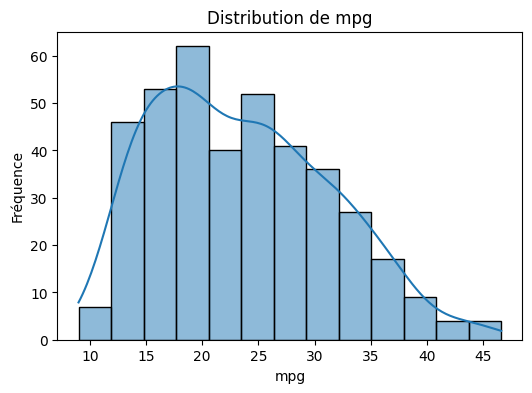

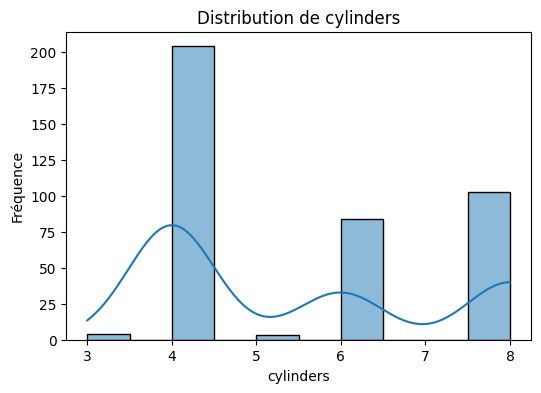

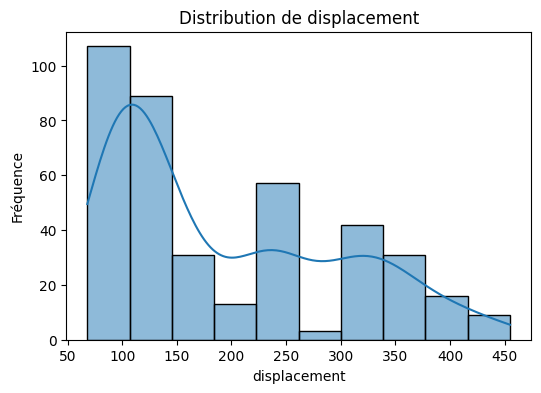

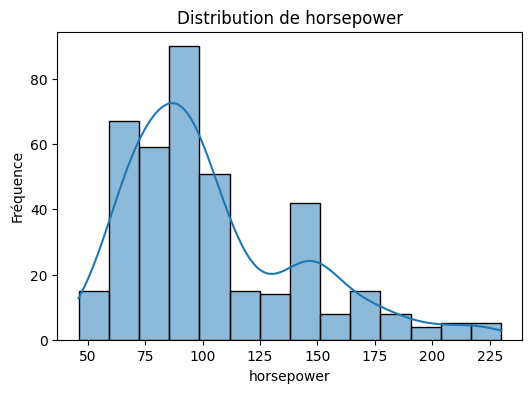

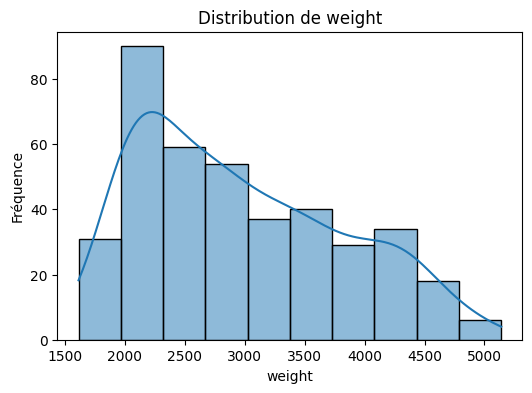

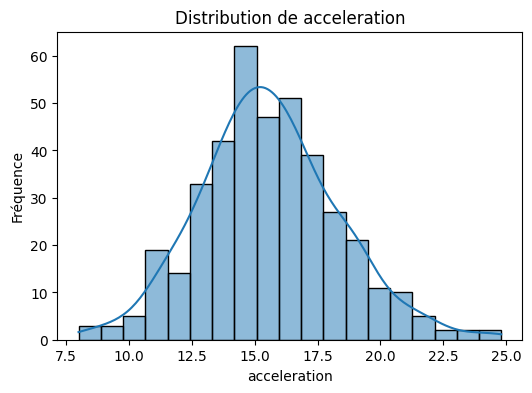

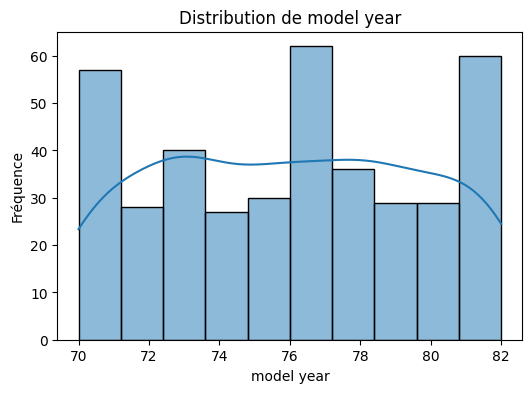

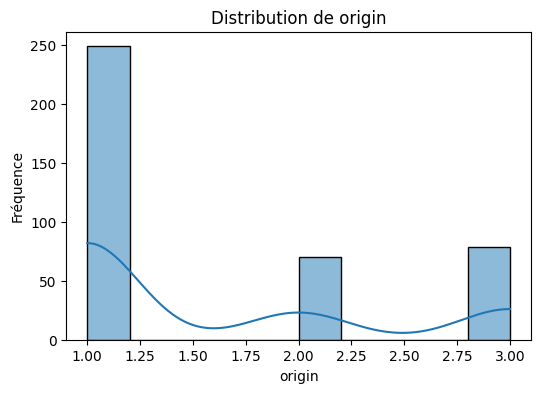

In [ ]:
num_cols = df_clean.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.show()

3. Boxplots

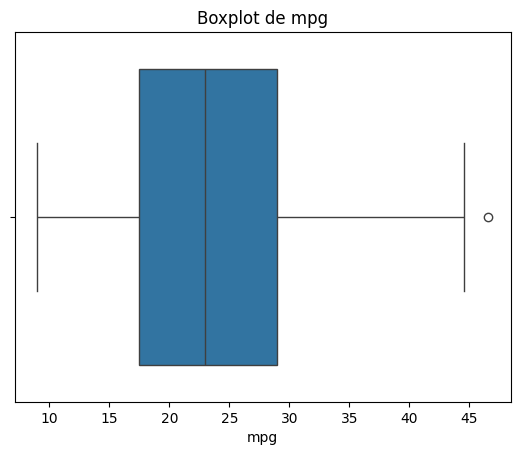

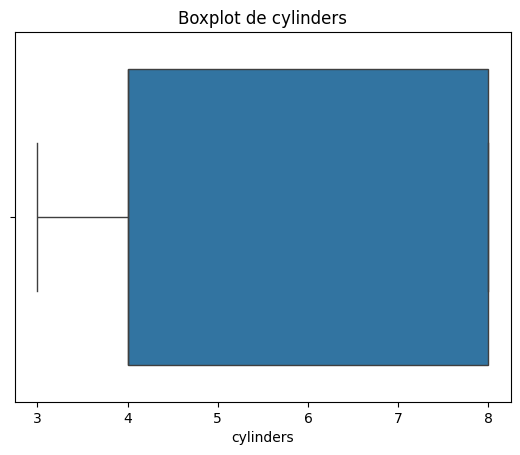

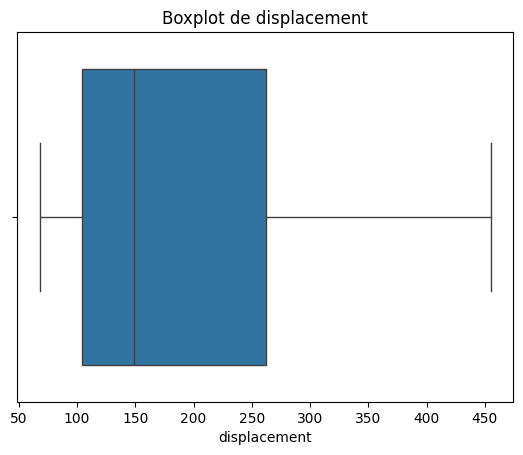

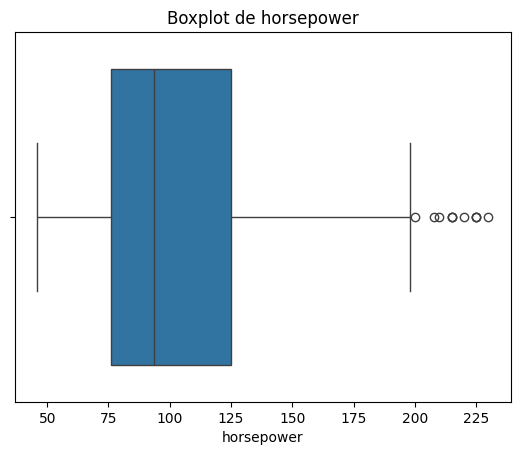

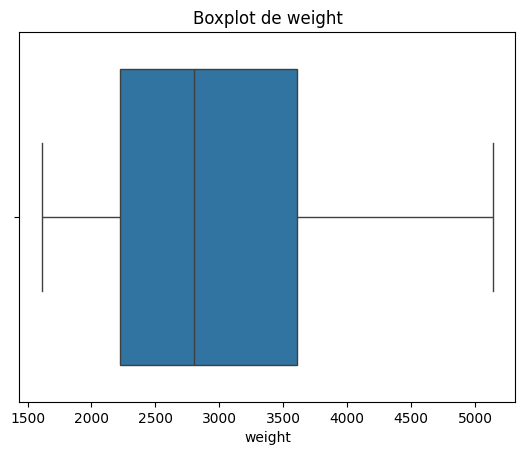

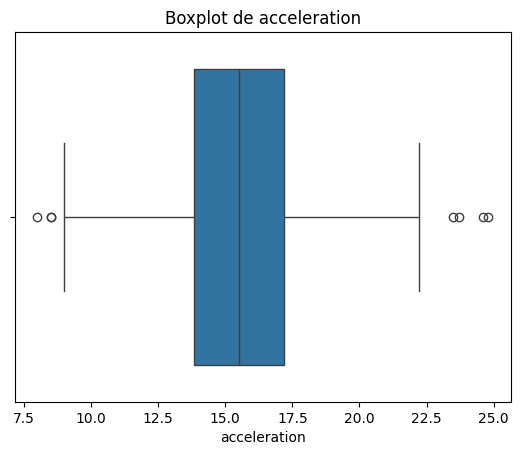

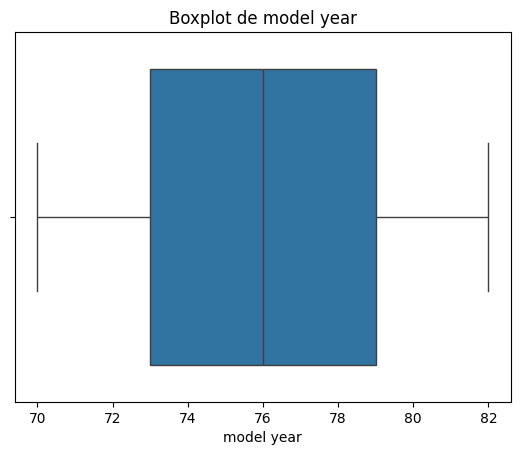

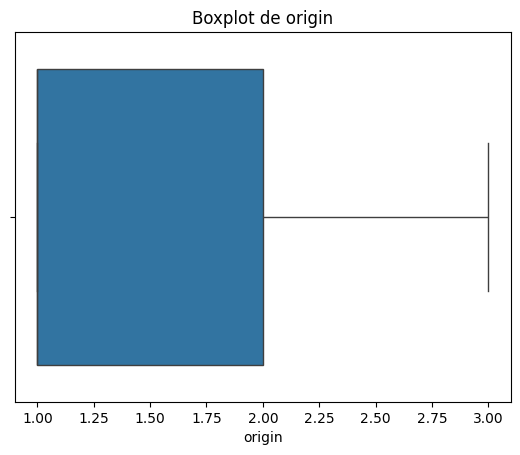

In [ ]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df_clean[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

4. Détection des outliers

In [ ]:
def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    outliers = series[(series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)]
    return len(outliers)

print("\nNombre de valeurs aberrantes détectées par variable :")
for var in num_cols:
    n_outliers = detect_outliers(df_clean[var])
    print(f"{var} : {n_outliers} valeurs aberrantes")


Nombre de valeurs aberrantes détectées par variable :
mpg : 1 valeurs aberrantes
cylinders : 0 valeurs aberrantes
displacement : 0 valeurs aberrantes
horsepower : 11 valeurs aberrantes
weight : 0 valeurs aberrantes
acceleration : 7 valeurs aberrantes
model year : 0 valeurs aberrantes
origin : 0 valeurs aberrantes


5. Préparation finale pour la régression

In [ ]:
x = df_clean.drop(columns=[target])
y = df_clean[target]
print("Variables explicatives :")
print(x.head())
print("\nVariable cible:")
print(y.head())

Variables explicatives :
   cylinders  displacement  horsepower  weight  acceleration  model year  \
0          8         307.0       130.0    3504          12.0          70   
1          8         350.0       165.0    3693          11.5          70   
2          8         318.0       150.0    3436          11.0          70   
3          8         304.0       150.0    3433          12.0          70   
4          8         302.0       140.0    3449          10.5          70   

   origin  
0       1  
1       1  
2       1  
3       1  
4       1  

Variable cible:
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


###Analyse descriptive bivariee:

1-Matrice de correlation

In [ ]:
correlation_matrix = df_clean.corr()

print("Matrice de corrélation :")
print(correlation_matrix.round(2))

Matrice de corrélation :
               mpg  cylinders  displacement  horsepower  weight  acceleration  \
mpg           1.00      -0.78         -0.80       -0.77   -0.83          0.42   
cylinders    -0.78       1.00          0.95        0.84    0.90         -0.51   
displacement -0.80       0.95          1.00        0.90    0.93         -0.54   
horsepower   -0.77       0.84          0.90        1.00    0.86         -0.69   
weight       -0.83       0.90          0.93        0.86    1.00         -0.42   
acceleration  0.42      -0.51         -0.54       -0.69   -0.42          1.00   
model year    0.58      -0.35         -0.37       -0.41   -0.31          0.29   
origin        0.56      -0.56         -0.61       -0.45   -0.58          0.21   

              model year  origin  
mpg                 0.58    0.56  
cylinders          -0.35   -0.56  
displacement       -0.37   -0.61  
horsepower         -0.41   -0.45  
weight             -0.31   -0.58  
acceleration        0.29    0.21  


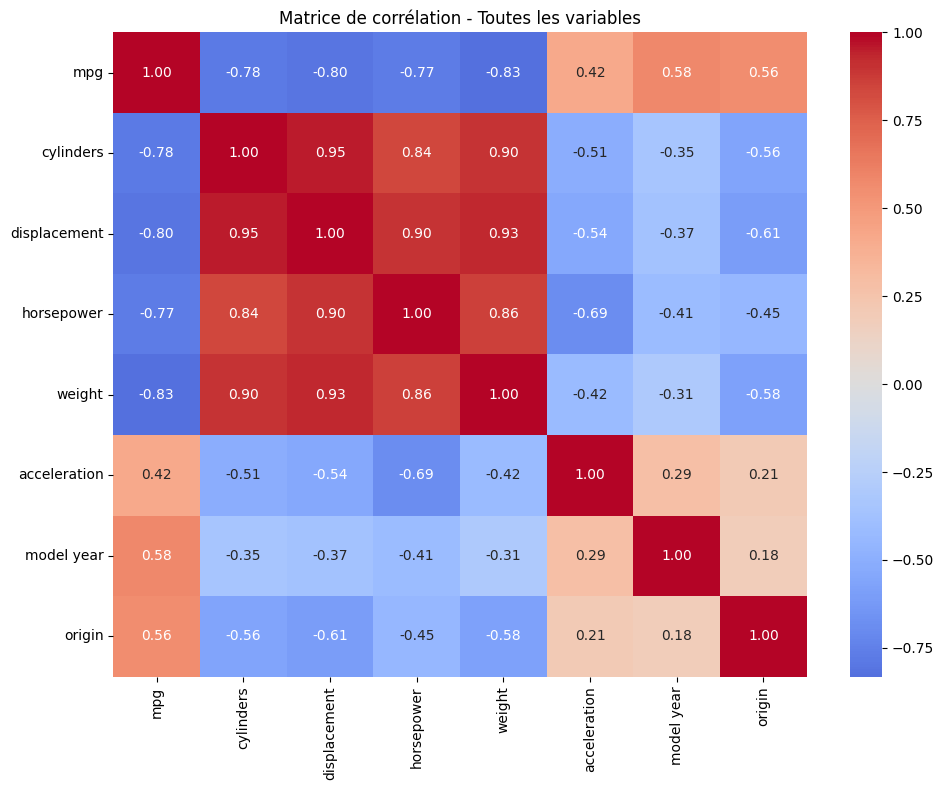

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matrice de corrélation - Toutes les variables')
plt.tight_layout()
plt.show()

2-Correlation avec la variable cible(mpg)

In [ ]:
# Corrélations avec mpg, triées par ordre décroissant
corr_with_mpg = correlation_matrix['mpg'].sort_values(ascending=False)

print("Corrélations avec la consommation (mpg) :")
print(corr_with_mpg)

Corrélations avec la consommation (mpg) :
mpg             1.000000
model year      0.579267
origin          0.563450
acceleration    0.420289
horsepower     -0.773453
cylinders      -0.775396
displacement   -0.804203
weight         -0.831741
Name: mpg, dtype: float64


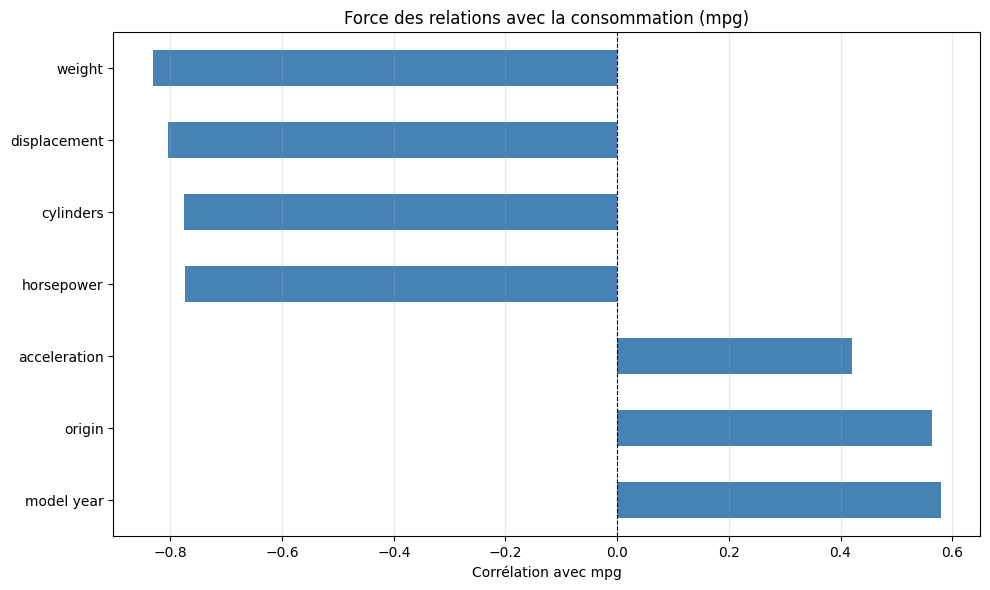

In [ ]:
# Graphique en barres des corrélations avec mpg
plt.figure(figsize=(10, 6))
corr_with_mpg.drop('mpg').plot(kind='barh', color='steelblue')
plt.xlabel('Corrélation avec mpg')
plt.title('Force des relations avec la consommation (mpg)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

3-Relation mpg vs weight

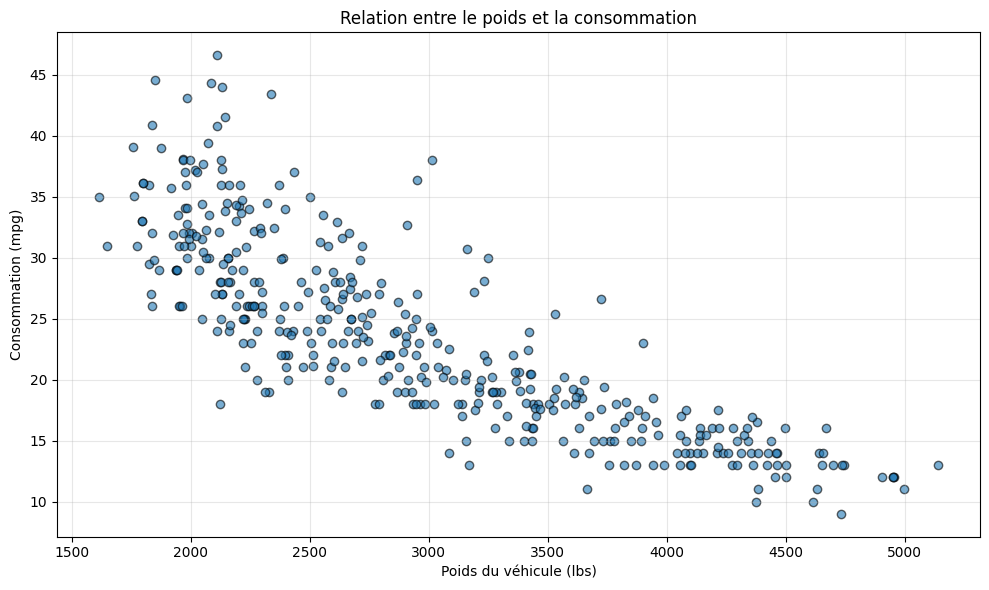

Corrélation mpg-weight : -0.832


In [ ]:
# Nuage de points : mpg en fonction du poids
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['weight'], df_clean['mpg'], alpha=0.6, edgecolors='k')
plt.xlabel('Poids du véhicule (lbs)')
plt.ylabel('Consommation (mpg)')
plt.title('Relation entre le poids et la consommation')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Corrélation mpg-weight : {df_clean['mpg'].corr(df_clean['weight']):.3f}")

4-Relation mpg vs displacement(cylindree)

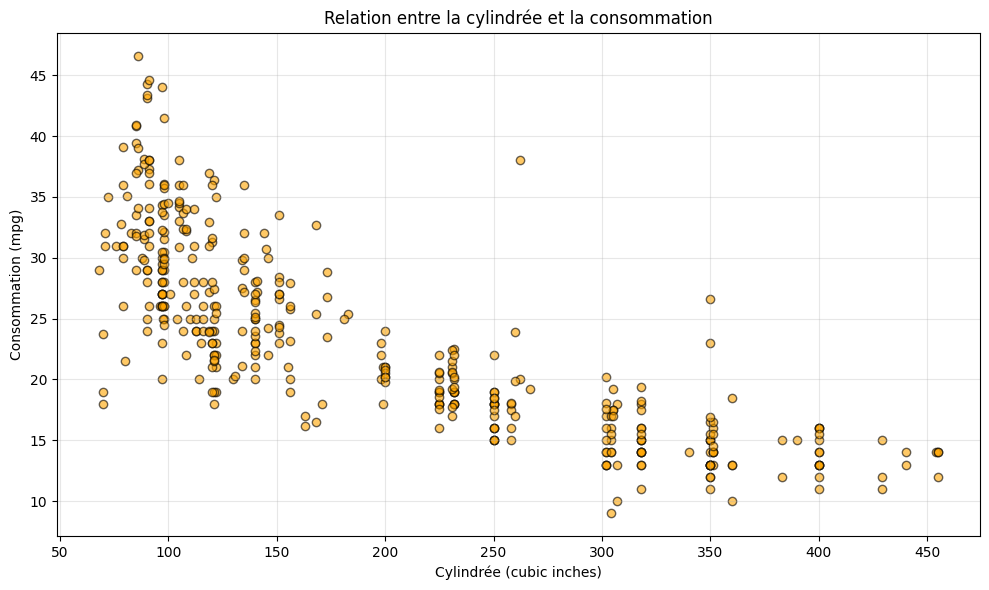

Corrélation mpg-displacement : -0.804


In [ ]:
# Nuage de points : mpg en fonction de la cylindrée
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['displacement'], df_clean['mpg'], alpha=0.6, color='orange', edgecolors='k')
plt.xlabel('Cylindrée (cubic inches)')
plt.ylabel('Consommation (mpg)')
plt.title('Relation entre la cylindrée et la consommation')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Corrélation mpg-displacement : {df_clean['mpg'].corr(df_clean['displacement']):.3f}")

5-Relation mpg vs horsepower(puissance)

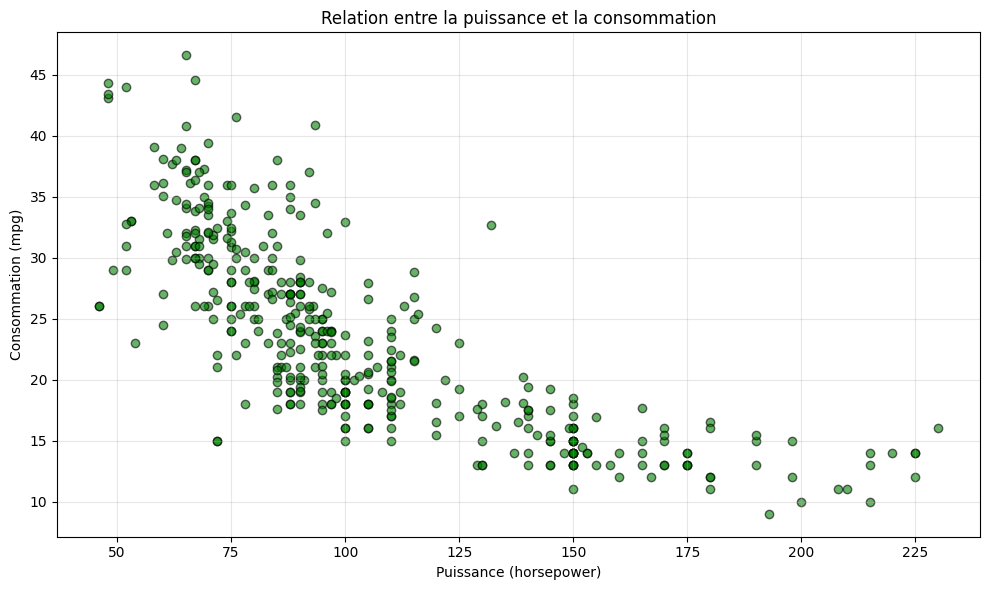

Corrélation mpg-horsepower : -0.773


In [ ]:
# Nuage de points : mpg en fonction de la puissance
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['horsepower'], df_clean['mpg'], alpha=0.6, color='green', edgecolors='k')
plt.xlabel('Puissance (horsepower)')
plt.ylabel('Consommation (mpg)')
plt.title('Relation entre la puissance et la consommation')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Corrélation mpg-horsepower : {df_clean['mpg'].corr(df_clean['horsepower']):.3f}")

6-Relation mpg vs model year(annee)

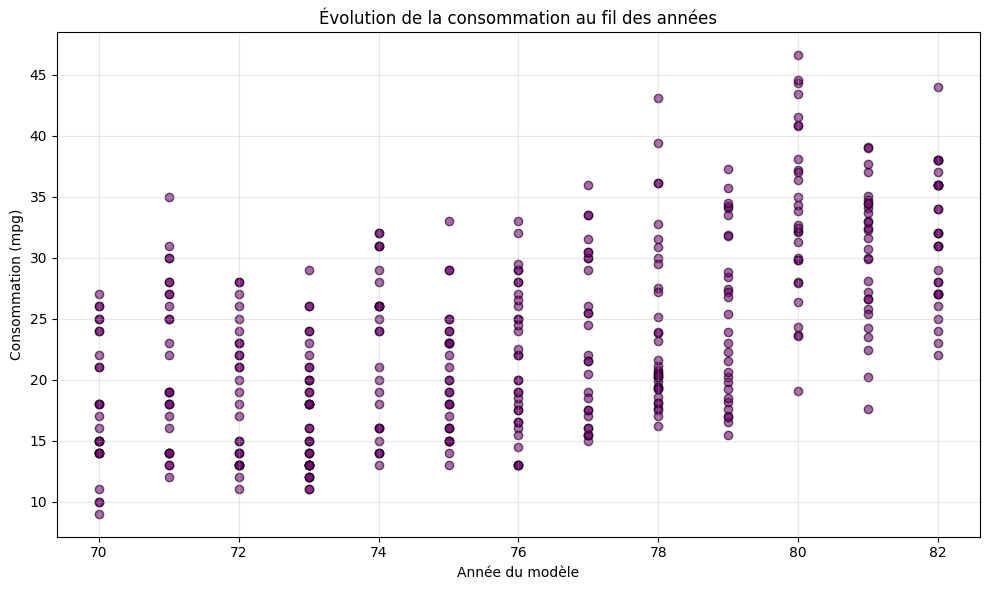

Corrélation mpg-model year : 0.579


In [ ]:
# Nuage de points : mpg en fonction de l'année
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['model year'], df_clean['mpg'], alpha=0.6, color='purple', edgecolors='k')
plt.xlabel('Année du modèle')
plt.ylabel('Consommation (mpg)')
plt.title('Évolution de la consommation au fil des années')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Corrélation mpg-model year : {df_clean['mpg'].corr(df_clean['model year']):.3f}")

7-Boxplot: mpg selon le nombre de cylindres

<Figure size 1000x600 with 0 Axes>

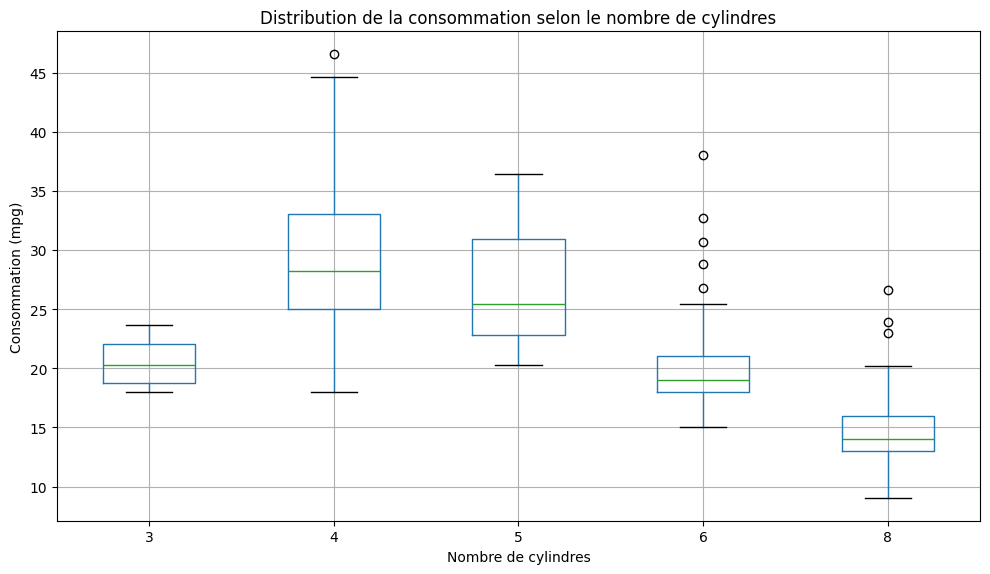

In [ ]:
# Boxplot : consommation par nombre de cylindres
plt.figure(figsize=(10, 6))
df_clean.boxplot(column='mpg', by='cylinders', figsize=(10, 6))
plt.suptitle('')  # Supprimer le titre automatique
plt.xlabel('Nombre de cylindres')
plt.ylabel('Consommation (mpg)')
plt.title('Distribution de la consommation selon le nombre de cylindres')
plt.tight_layout()
plt.show()

8-Boxplot: mpg selon l'origine

<Figure size 1000x600 with 0 Axes>

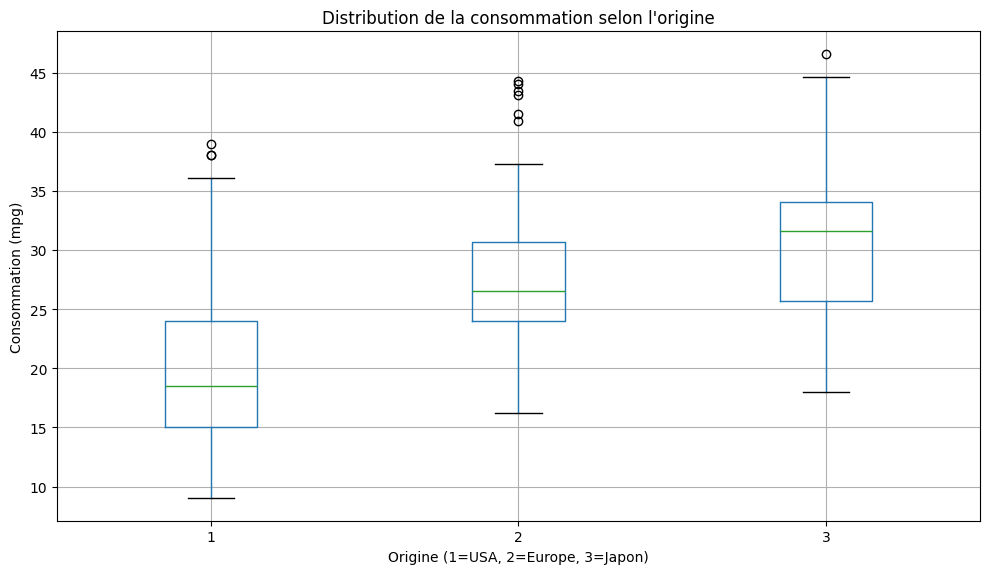

In [ ]:
# Boxplot : consommation par origine
plt.figure(figsize=(10, 6))
df_clean.boxplot(column='mpg', by='origin', figsize=(10, 6))
plt.suptitle('')  # Supprimer le titre automatique
plt.xlabel('Origine (1=USA, 2=Europe, 3=Japon)')
plt.ylabel('Consommation (mpg)')
plt.title('Distribution de la consommation selon l\'origine')
plt.tight_layout()
plt.show()

10-Synthese

In [ ]:
print("SYNTHÈSE DES RÉSULTATS")
# Create a series of correlations excluding 'mpg' itself
corr_with_other_vars = corr_with_mpg.drop('mpg')

print("\n Variables avec CORRÉLATION NÉGATIVE forte (diminuent mpg) :")
negative_corr = corr_with_other_vars[corr_with_other_vars < -0.5]
for var, corr in negative_corr.items():
    print(f"  • {var:15s} : {corr:+.3f}")

print("\n Variables avec CORRÉLATION POSITIVE (augmentent mpg) :")
positive_corr = corr_with_other_vars[corr_with_other_vars > 0.3]
for var, corr in positive_corr.items():
    print(f"  • {var:15s} : {corr:+.3f}")

print("CONCLUSION :")
print("Les variables les plus influentes sur la consommation sont :")
top_3 = corr_with_other_vars.abs().sort_values(ascending=False).head(3)
for i, (var, corr) in enumerate(top_3.items(), 1):
    actual_corr = corr_with_mpg[var]
    print(f"{i}. {var} (corrélation = {actual_corr:+.3f})")

SYNTHÈSE DES RÉSULTATS

 Variables avec CORRÉLATION NÉGATIVE forte (diminuent mpg) :
  • horsepower      : -0.773
  • cylinders       : -0.775
  • displacement    : -0.804
  • weight          : -0.832

 Variables avec CORRÉLATION POSITIVE (augmentent mpg) :
  • model year      : +0.579
  • origin          : +0.563
  • acceleration    : +0.420
CONCLUSION :
Les variables les plus influentes sur la consommation sont :
1. weight (corrélation = -0.832)
2. displacement (corrélation = -0.804)
3. cylinders (corrélation = -0.775)


## Construction et évaluation des modèles de régression linéaire

### 1. Objectif de la modélisation

L’objectif de cette étape est de mettre en œuvre techniquement trois modèles de régression linéaire simple afin de prédire la consommation de carburant des véhicules (mpg) à partir de trois variables explicatives :
* le poids du véhicule (weight)

* la puissance du moteur (horsepower)

* la cylindrée (displacement)

Chaque modèle est ensuite évalué à l’aide d’indicateurs statistiques standards afin d’identifier la variable la plus pertinente pour expliquer la consommation.

### 2. Méthodologie de modélisation

Pour chaque variable explicative :

1. Séparation des données en ensemble d’apprentissage (80 %) et ensemble de test (20 %)

2. Entraînement d’un modèle de régression linéaire simple

3. Prédiction des valeurs de mpg sur l’ensemble de test

4. Calcul des indicateurs de performance :

   * Coefficient de régression

   * Intercept

   * Coefficient de détermination R²

   * MSE, RMSE, MAE

5. Visualisation du nuage de points et de la droite de régression

### 3. Fonction générique de construction d’un modèle

In [ ]:
def construire_modele(variable):
    X = df_clean[[variable]]
    y = df_clean["mpg"]

    # Séparation apprentissage / test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Entraînement du modèle
    modele = LinearRegression()
    modele.fit(X_train, y_train)

    # Prédictions
    y_pred = modele.predict(X_test)

    # Indicateurs statistiques
    coef = modele.coef_[0]
    intercept = modele.intercept_
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)

    # Visualisation
    plt.figure(figsize=(6, 4))
    plt.scatter(X_test, y_test)
    plt.plot(X_test, y_pred)
    plt.xlabel(variable)
    plt.ylabel("mpg")
    plt.title(f"Régression linéaire : mpg ~ {variable}")
    plt.grid(True)
    plt.show()

    return {
        "Variable": variable,
        "Coefficient": coef,
        "Intercept": intercept,
        "R²": r2,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae
    }

### 4. Construction des trois modèles:

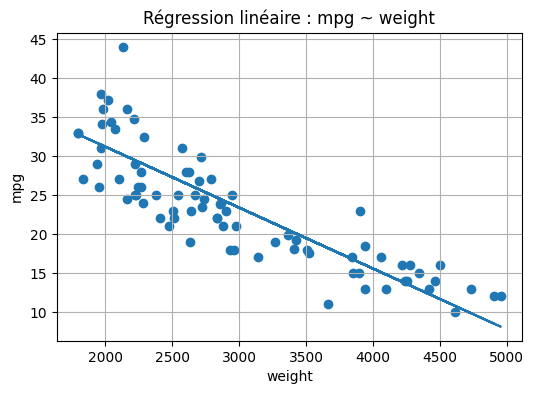

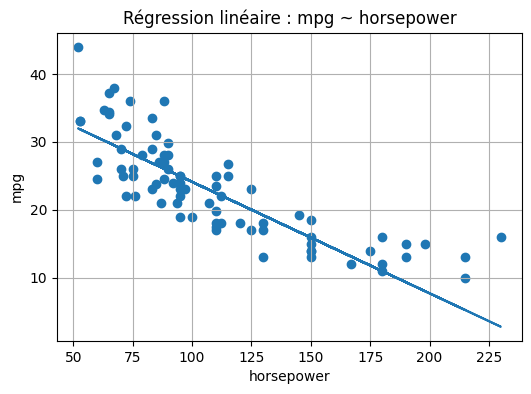

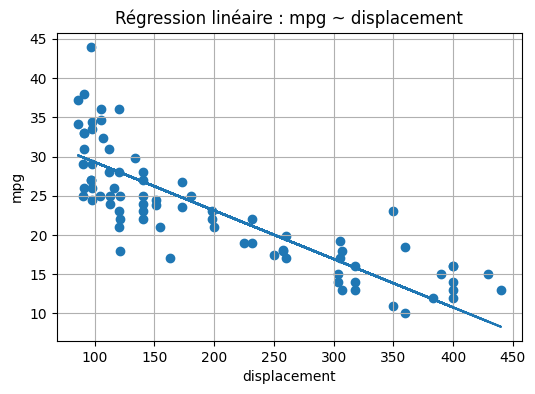

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

variables = ["weight", "horsepower", "displacement"]

resultats = [construire_modele(var) for var in variables]

tableau_resultats = pd.DataFrame(resultats)

In [ ]:
tableau_resultats

,Variable,Coefficient,Intercept,R²,MSE,RMSE,MAE
0,weight,-0.007805,46.782063,0.722971,14.894861,3.859386,3.117786
1,horsepower,-0.163957,40.517164,0.639680,19.373139,4.401493,3.508906
2,displacement,-0.061725,35.453495,0.663311,18.102544,4.254708,3.394960


#La régression linéaire simple (RLS)

Definition : est une technique statistique qui permet de modéliser la relation entre une variable dépendante (Y) et une variable indépendante (X). Dans notre cas, nous cherchons à prédire la consommation de carburant (mpg) à partir de différentes caractéristiques des véhicules.

##ANALYSE DES HYPOTHÈSES DE LA RÉGRESSION LINÉAIRE

Cependant, pour que les résultats d'une régression linéaire soient fiables et interprétables, le modèle doit respecter certaines conditions appelées "hypothèses".

Si les hypothèses ne sont pas respectées, les résultats du modèle peuvent être biaises , non fiables et trompeurs.

Préparation des données

In [ ]:
X_weight=df_clean[['weight']]
X_horsepower=df_clean[['horsepower']]
X_displacement=df_clean[['displacement']]
y=df_clean['mpg']

X_weight_train, X_weight_test, y_train, y_test = train_test_split(X_weight, y, test_size=0.2,random_state=42)
X_hp_train, X_hp_test, y_train_hp , y_test_hp=train_test_split(X_horsepower, y, test_size=0.2, random_state=42)
X_disp_train, X_disp_test, y_train_disp, y_test_disp=train_test_split(X_displacement, y, test_size=0.2, random_state=42)

print("Données séparées en train (80%) et test (20%)")
print(f"Taille train : {len(X_weight_train)}")
print(f"Taille test : {len(X_weight_test)}")

Données séparées en train (80%) et test (20%)
Taille train : 318
Taille test : 80


## Construction des 3 modeles

On construit 3 modèles de régression linéaire simple (une seule variable explicative) pour prédire mpg. Cela permet de comparer quelle variable prédit le mieux la consommation.

In [ ]:
#modele 1: mpg avec weight
model_weight = LinearRegression()
model_weight.fit(X_weight_train, y_train)

#modele 2 : mpg avec horsepower
model_hp = LinearRegression()
model_hp.fit(X_hp_train, y_train_hp)

#modele 3: mpg avec displacement
model_disp=LinearRegression()
model_disp.fit(X_disp_train, y_train_disp)

LinearRegression()

 les prédictions et résidus

In [ ]:
# Prédictions sur l'ensemble d'entraînement
y_pred_weight = model_weight.predict(X_weight_train)
y_pred_hp = model_hp.predict(X_hp_train)
y_pred_disp = model_disp.predict(X_disp_train)

# Calcul des résidus (erreur = valeur réelle - valeur prédite)
residus_weight = y_train - y_pred_weight
residus_hp = y_train_hp - y_pred_hp
residus_disp = y_train_disp - y_pred_disp

print(" Résidus calculés pour les 3 modèles")
print(f"\nExemple résidus weight : {residus_weight[:5].values}")

 Résidus calculés pour les 3 modèles

Exemple résidus weight : [-3.98666637 -3.15689716  6.0235524   3.36737287 -2.75474047]


###Les 4 hypothèses fondamentales de la régression linéaire

1- Hypothèse de LINÉARITÉ

La relation entre X et Y doit être linéaire (une ligne droite). Si la relation est courbe, la régression linéaire ne sera pas adaptée.

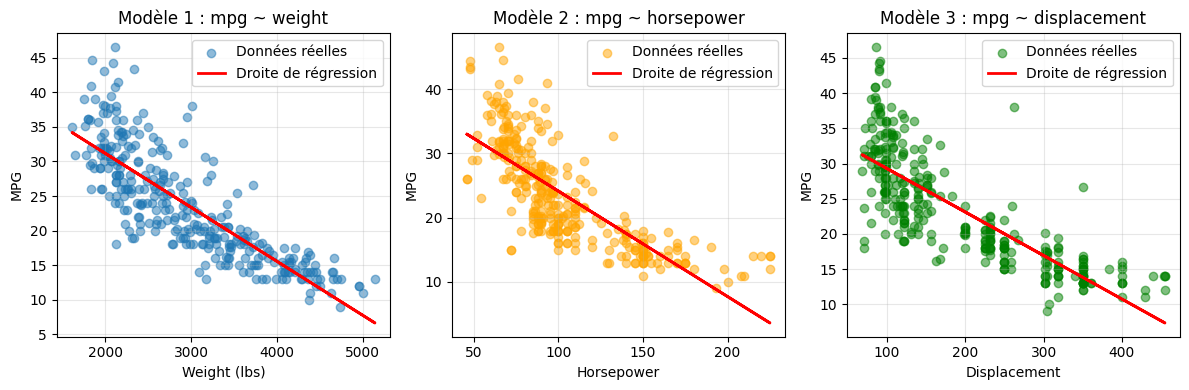

 Interprétation : Si les points suivent globalement la droite rouge, la relation est linéaire.


In [ ]:
# MODÈLE 1 : mpg ~ weight
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(X_weight_train, y_train, alpha=0.5, label='Données réelles')
plt.plot(X_weight_train, y_pred_weight, color='red', linewidth=2, label='Droite de régression')
plt.xlabel('Weight (lbs)')
plt.ylabel('MPG')
plt.title('Modèle 1 : mpg ~ weight')
plt.legend()
plt.grid(alpha=0.3)

# MODÈLE 2 : mpg ~ horsepower
plt.subplot(1, 3, 2)
plt.scatter(X_hp_train, y_train_hp, alpha=0.5, label='Données réelles', color='orange')
plt.plot(X_hp_train, y_pred_hp, color='red', linewidth=2, label='Droite de régression')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('Modèle 2 : mpg ~ horsepower')
plt.legend()
plt.grid(alpha=0.3)

# MODÈLE 3 : mpg ~ displacement
plt.subplot(1, 3, 3)
plt.scatter(X_disp_train, y_train_disp, alpha=0.5, label='Données réelles', color='green')
plt.plot(X_disp_train, y_pred_disp, color='red', linewidth=2, label='Droite de régression')
plt.xlabel('Displacement')
plt.ylabel('MPG')
plt.title('Modèle 3 : mpg ~ displacement')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(" Interprétation : Si les points suivent globalement la droite rouge, la relation est linéaire.")

2-HYPOTHÈSE 2 : NORMALITÉ DES RÉSIDUS

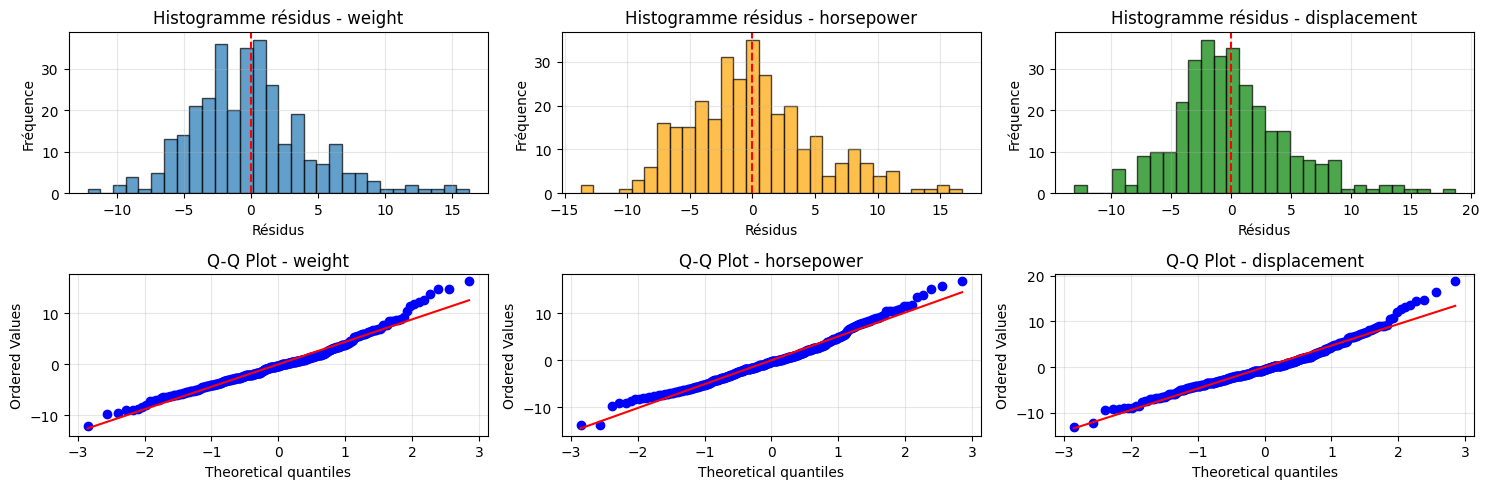

 Interprétation :
Histogramme en cloche + Q-Q plot aligné = normalité respectée
 Histogramme asymétrique + Q-Q plot courbé = normalité violée


In [ ]:
# HISTOGRAMMES DES RÉSIDUS
plt.figure(figsize=(15, 5))

# Modèle 1 : weight
plt.subplot(2, 3, 1)
plt.hist(residus_weight, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Résidus')
plt.ylabel('Fréquence')
plt.title('Histogramme résidus - weight')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
plt.grid(alpha=0.3)

# Modèle 2 : horsepower
plt.subplot(2, 3, 2)
plt.hist(residus_hp, bins=30, edgecolor='black', alpha=0.7, color='orange')
plt.xlabel('Résidus')
plt.ylabel('Fréquence')
plt.title('Histogramme résidus - horsepower')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
plt.grid(alpha=0.3)

# Modèle 3 : displacement
plt.subplot(2, 3, 3)
plt.hist(residus_disp, bins=30, edgecolor='black', alpha=0.7, color='green')
plt.xlabel('Résidus')
plt.ylabel('Fréquence')
plt.title('Histogramme résidus - displacement')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
plt.grid(alpha=0.3)

# Q-Q PLOTS (comparaison avec loi normale théorique)
# Modèle 1 : weight
plt.subplot(2, 3, 4)
stats.probplot(residus_weight, dist="norm", plot=plt)
plt.title('Q-Q Plot - weight')
plt.grid(alpha=0.3)

# Modèle 2 : horsepower
plt.subplot(2, 3, 5)
stats.probplot(residus_hp, dist="norm", plot=plt)
plt.title('Q-Q Plot - horsepower')
plt.grid(alpha=0.3)

# Modèle 3 : displacement
plt.subplot(2, 3, 6)
stats.probplot(residus_disp, dist="norm", plot=plt)
plt.title('Q-Q Plot - displacement')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(" Interprétation :")
print("Histogramme en cloche + Q-Q plot aligné = normalité respectée")
print(" Histogramme asymétrique + Q-Q plot courbé = normalité violée")

3-HYPOTHÈSE 3 : HOMOSCÉDASTICITÉ

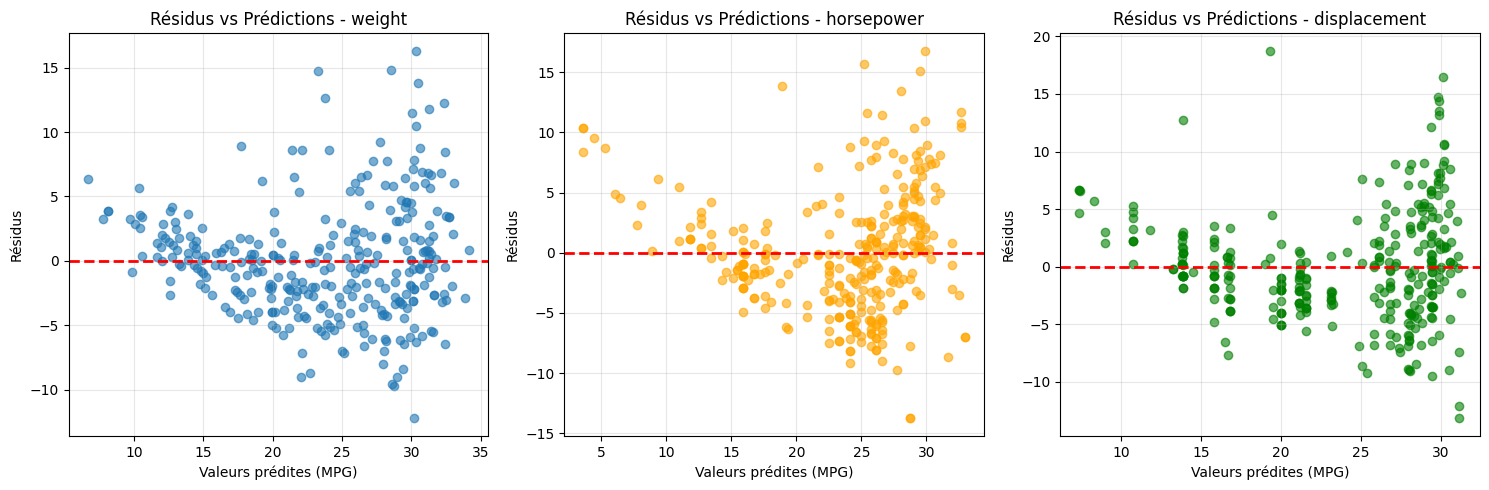

 Interprétation :
Points aléatoires autour de 0 sans motif = homoscédasticité respectée
Forme d'entonnoir (variance qui augmente) = hétéroscédasticité


In [ ]:
# RÉSIDUS VS VALEURS PRÉDITES
plt.figure(figsize=(15, 5))

# Modèle 1 : weight
plt.subplot(1, 3, 1)
plt.scatter(y_pred_weight, residus_weight, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Valeurs prédites (MPG)')
plt.ylabel('Résidus')
plt.title('Résidus vs Prédictions - weight')
plt.grid(alpha=0.3)

# Modèle 2 : horsepower
plt.subplot(1, 3, 2)
plt.scatter(y_pred_hp, residus_hp, alpha=0.6, color='orange')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Valeurs prédites (MPG)')
plt.ylabel('Résidus')
plt.title('Résidus vs Prédictions - horsepower')
plt.grid(alpha=0.3)

# Modèle 3 : displacement
plt.subplot(1, 3, 3)
plt.scatter(y_pred_disp, residus_disp, alpha=0.6, color='green')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Valeurs prédites (MPG)')
plt.ylabel('Résidus')
plt.title('Résidus vs Prédictions - displacement')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(" Interprétation :")
print("Points aléatoires autour de 0 sans motif = homoscédasticité respectée")
print("Forme d'entonnoir (variance qui augmente) = hétéroscédasticité")

## Comparaison des modèles

Les performances des trois modèles de régression linéaire simple ont été comparées à l’aide des indicateurs R², RMSE et MAE.
Ces indicateurs permettent d’évaluer la qualité d’ajustement et la précision des prédictions.

| Modèle | Variable | R² | RMSE | MAE |
|------|--------|-----|------|------|
| mpg ~ weight | Weight | 0.722971 | 3.859386 | 3.117786 |
| mpg ~ horsepower | Horsepower | 0.639680 | 4.401493 | 3.508906 |
| mpg ~ displacement | Displacement | 0.663311 | 4.254708 | 3.394960 |


### Choix du meilleur modèle

Le modèle mpg ~ weight présente le coefficient de détermination R² le plus élevé ainsi que les plus faibles valeurs de RMSE et MAE.
Il est donc considéré comme le modèle offrant les meilleures performances.

Ainsi, le poids du véhicule est la variable explicative la plus pertinente pour prédire la consommation de carburant (mpg).


### Comparaison SPSS vs Python

Les résultats obtenus avec SPSS et Python sont globalement similaires et conduisent au même classement des modèles.
Les légères différences observées sont dues aux méthodes de calcul internes et aux arrondis numériques.

Dans les deux environnements, le modèle mpg ~ weight apparaît comme le meilleur modèle.


### Conclusion de la comparaison

Parmi les trois modèles étudiés, le modèle basé sur le poids du véhicule offre le meilleur compromis entre pouvoir explicatif et précision des prédictions.
Ce modèle sera donc retenu pour la suite de l’étude.


#Micro-activité : Extension a plusieurs variables

##Preparation des donnees

In [ ]:
# Convertir horsepower en numérique
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")

# Remplir les valeurs manquantes avec la médiane
df["horsepower"].fillna(df["horsepower"].median(), inplace=True)

# Supprimer les doublons
df = df.drop_duplicates()

# Supprimer la colonne car name (inutile pour la régression)
df_clean = df.drop(columns=["car name"])
print("Valeurs manquantes restantes :")
print(df_clean.isnull().sum())

Valeurs manquantes restantes :
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
dtype: int64


/tmp/ipykernel_7960/768575560.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["horsepower"].fillna(df["horsepower"].median(), inplace=True)


In [ ]:
# Variable : mpg (consommation)
y = df_clean["mpg"]

# Variables explicatives : tout sauf mpg
X = df_clean.drop(columns=["mpg"])

print("Variables explicatives utilisées :")
print(list(X.columns))
print(f"\nNombre d'observations : {len(y)}")

Variables explicatives utilisées :
['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin']

Nombre d'observations : 398


##Construction du modele

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Taille train : {X_train.shape[0]} lignes")
print(f"Taille test  : {X_test.shape[0]} lignes")
# Création et entraînement du modèle
modele_multiple = LinearRegression()
modele_multiple.fit(X_train, y_train)

print("Modèle entraîné avec succès !")

# Affichage de la formule du modèle
print(f"Intercept (constante) : {modele_multiple.intercept_:.4f}")
print()
print("Coefficients :")
for var, coef in zip(X.columns, modele_multiple.coef_):
    print(f"  {var:15s} : {coef:.4f}")

Taille train : 318 lignes
Taille test  : 80 lignes
Modèle entraîné avec succès !
Intercept (constante) : -20.5593

Coefficients :
  cylinders       : -0.1568
  displacement    : 0.0142
  horsepower      : -0.0132
  weight          : -0.0067
  acceleration    : 0.0688
  model year      : 0.7950
  origin          : 1.3230


##Évaluation (R², RMSE, MAE)

In [ ]:
# Prédictions sur le jeu de test
y_pred_multiple = modele_multiple.predict(X_test)

# Calcul des métriques
r2   = r2_score(y_test, y_pred_multiple)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_multiple))
mae  = mean_absolute_error(y_test, y_pred_multiple)

print(f"R²   = {r2:.4f}  → Le modèle explique {r2*100:.1f}% de la variance")
print(f"RMSE = {rmse:.4f} mpg")
print(f"MAE  = {mae:.4f} mpg")

R²   = 0.8475  → Le modèle explique 84.8% de la variance
RMSE = 2.8632 mpg
MAE  = 2.2554 mpg


##Interprétation des coefficients

In [ ]:
# Tableau des coefficients
tableau_coef = pd.DataFrame({
    "Variable"   : X.columns,
    "Coefficient": modele_multiple.coef_
})

# Colonne effet
tableau_coef["Effet"] = tableau_coef["Coefficient"].apply(
    lambda c: "↑ Augmente mpg" if c > 0 else "↓ Diminue mpg"
)

# Tri par valeur absolue
tableau_coef["Abs"] = tableau_coef["Coefficient"].abs()
tableau_coef = tableau_coef.sort_values("Abs", ascending=False).drop(columns="Abs")

print(tableau_coef.to_string(index=False))
print(f"\nConstante (intercept) = {modele_multiple.intercept_:.4f}")

    Variable  Coefficient          Effet
      origin     1.322959 ↑ Augmente mpg
  model year     0.794960 ↑ Augmente mpg
   cylinders    -0.156793  ↓ Diminue mpg
acceleration     0.068776 ↑ Augmente mpg
displacement     0.014220 ↑ Augmente mpg
  horsepower    -0.013187  ↓ Diminue mpg
      weight    -0.006746  ↓ Diminue mpg

Constante (intercept) = -20.5593


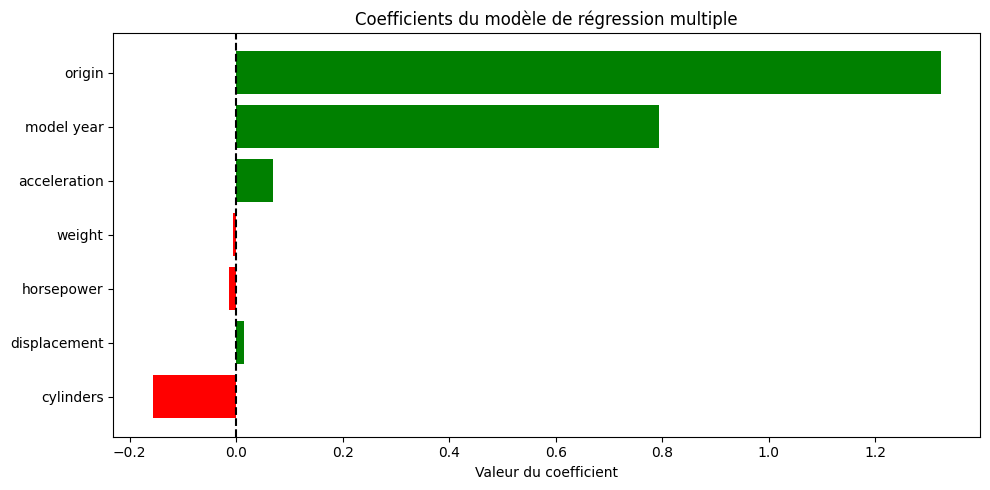

In [ ]:
# Graphique des coefficients
plt.figure(figsize=(10, 5))
colors = ["green" if c > 0 else "red" for c in modele_multiple.coef_]
plt.barh(list(X.columns), modele_multiple.coef_, color=colors)
plt.axvline(x=0, color="black", linestyle="--")
plt.xlabel("Valeur du coefficient")
plt.title("Coefficients du modèle de régression multiple")
plt.tight_layout()
plt.show()

##Comparaison Simple vs Multiple

In [ ]:
# Fonction pour tester un modèle simple (une seule variable)
def regression_simple(variable):
    X_simple = df_clean[[variable]]
    y_simple  = df_clean["mpg"]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_simple, y_simple, test_size=0.2, random_state=42
    )

    modele = LinearRegression()
    modele.fit(X_tr, y_tr)
    y_pred = modele.predict(X_te)

    return {
        "Modèle": f"Simple ({variable})",
        "R²"    : round(r2_score(y_te, y_pred), 4),
        "RMSE"  : round(np.sqrt(mean_squared_error(y_te, y_pred)), 4),
        "MAE"   : round(mean_absolute_error(y_te, y_pred), 4)
    }

# Test des 3 variables principales
resultats = [regression_simple(v) for v in ["weight", "horsepower", "displacement"]]

# Ajout du modèle multiple
resultats.append({
    "Modèle": "Multiple (toutes variables)",
    "R²"    : round(r2, 4),
    "RMSE"  : round(rmse, 4),
    "MAE"   : round(mae, 4)
})

# Tableau comparatif
tableau_comparaison = pd.DataFrame(resultats)
print(" SIMPLE vs MULTIPLE ")
print(tableau_comparaison.to_string(index=False))

 SIMPLE vs MULTIPLE 
                     Modèle     R²   RMSE    MAE
            Simple (weight) 0.7230 3.8594 3.1178
        Simple (horsepower) 0.6397 4.4015 3.5089
      Simple (displacement) 0.6633 4.2547 3.3950
Multiple (toutes variables) 0.8475 2.8632 2.2554


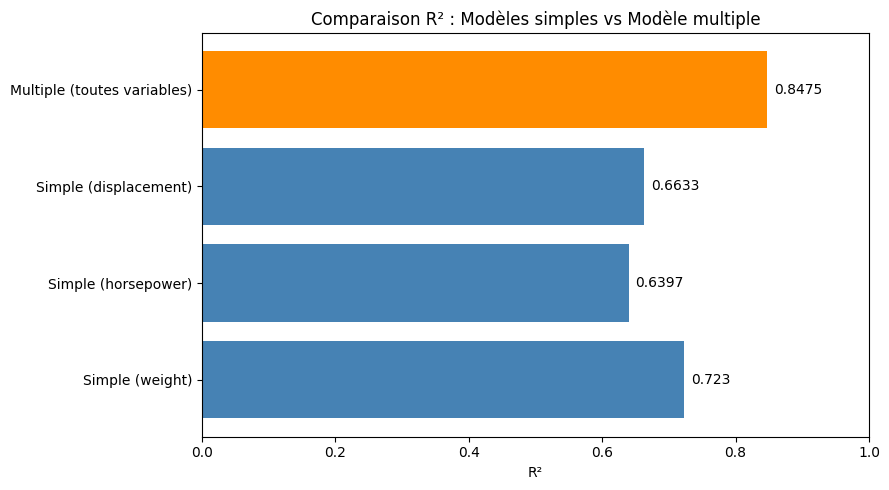

In [ ]:
# Graphique comparaison R²
plt.figure(figsize=(9, 5))
couleurs = ["steelblue", "steelblue", "steelblue", "darkorange"]
plt.barh(tableau_comparaison["Modèle"], tableau_comparaison["R²"], color=couleurs)
plt.xlabel("R²")
plt.title("Comparaison R² : Modèles simples vs Modèle multiple")
plt.xlim(0, 1)
for i, v in enumerate(tableau_comparaison["R²"]):
    plt.text(v + 0.01, i, str(v), va="center")
plt.tight_layout()
plt.show()

#Micro-activité : Multicolinéarité

###Matrice de corrélation

                weight  horsepower  displacement
weight        1.000000    0.862442      0.932824
horsepower    0.862442    1.000000      0.895778
displacement  0.932824    0.895778      1.000000


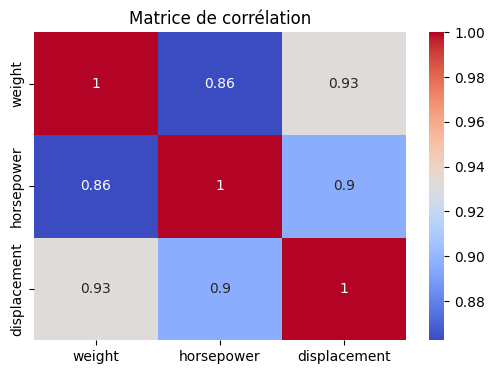

In [ ]:
# Sélection des variables explicatives
X = df[['weight', 'horsepower', 'displacement']]

# Matrice de corrélation
corr_matrix = X.corr()

print(corr_matrix)

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

####Interprétation
* weight et displacement (0.93) → très fortement corrélées
* horsepower et displacement (0.90) → très fortement corrélées
* weight et horsepower (0.86) → fortement corrélées

###Variance Inflation Factor(VIF)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Ajouter constante
X_const = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i)
                   for i in range(X_const.shape[1])]

print(vif_data)

       Variable        VIF
0         const  31.393757
1        weight   7.924344
2    horsepower   5.207422
3  displacement  10.275070


####Interprétation :
* displacement (10.27) → forte multicolinéarité
* weight (7.92) → colinéarité modérée élevée
* horsepower (5.20) → colinéarité modérée


### Conclusion :


L’analyse combinée de la matrice de corrélation et du VIF montre une forte dépendance linéaire entre les variables explicatives, notamment pour la variable displacement. Cette multicolinéarité peut affecter la stabilité et l’interprétation des coefficients du modèle de régression multiple.

# **Sélection des variables**

**Méthodologie de sélection**

L’objectif de cette activité est d’identifier le meilleur sous-ensemble de variables explicatives permettant de prédire la variable cible avec les meilleures performances possibles.

Pour cela, nous avons utilisé une approche de sélection manuelle progressive basée sur la comparaison de plusieurs modèles construits avec différentes combinaisons de variables. La démarche suivie est la suivante :

*   Construction d’un modèle avec chaque variable prise individuellement

*   Construction de modèles avec des combinaisons de deux variables

*   Construction du modèle avec toutes les variables

**Comparaison des performances de chaque modèle**

Les critères d’évaluation utilisés sont :

-Le coefficient de détermination R²

-La racine de l’erreur quadratique moyenne (RMSE)

L’erreur absolue moyenne (MAE)

Le meilleur modèle est celui qui maximise R² et minimise RMSE et MAE tout en restant simple et interprétable.

**Tableau comparatif des modèles **

| Variables utilisées                | R² (test)    | RMSE         | MAE          |
| ---------------------------------- | ------------ | ------------ | ------------ |
| weight                             | 0.722971     | 3.859386     | 3.117786     |
| horsepower                         | 0.639680     | 4.401493     | 3.508906     |
| displacement                       | 0.663311     | 4.254708     | 3.394960     |
| weight + horsepower                | **0.727303** | **3.829089** | **3.127688** |
| weight + displacement              | 0.721172     | 3.871894     | 3.115971     |
| horsepower + displacement          | 0.674524     | 4.183264     | 3.343563     |
| weight + horsepower + displacement | 0.725281     | 3.843262     | 3.125776     |

*Après comparaison des différentes combinaisons, le modèle utilisant :*

weight et horsepower

présente les meilleures performances avec un coefficient R² plus élevé et des erreurs RMSE et MAE plus faibles que les autres modèles.

Cela indique que ces variables expliquent mieux la variabilité de la variable cible et constituent le sous-ensemble optimal pour la prédiction.

Justification du choix final

Le choix final du modèle repose sur plusieurs critères :

*   De meilleures performances prédictives

*   Une complexité raisonnable du modèle

*   Une interprétation cohérente des variables retenues

L’ajout d’autres variables n’améliore pas significativement les performances, ce qui montre qu’elles apportent peu d’information supplémentaire et peuvent être considérées comme inutiles dans le modèle final.

**Micro-activité : Test d’ajout et suppression de variables**

Les expérimentations réalisées montrent que certaines variables améliorent fortement la qualité du modèle lorsqu’elles sont ajoutées, tandis que d’autres ont un impact plus faible. Nous avons également observé que l’ajout excessif de variables peut parfois dégrader les performances sur les données de test, ce qui peut être lié à un phénomène de sur-apprentissage.

.

Cette étape de sélection est donc essentielle pour obtenir un modèle performant et généralisable.

**Conclusion de la partie **

La sélection des variables a permis d’identifier le sous-ensemble optimal offrant le meilleur compromis entre précision et simplicité. Cette étape contribue à améliorer la capacité de généralisation du modèle tout en évitant l’utilisation de variables inutiles.

In [ ]:
# =============================
# VARIABLES (à adapter si besoin)
# =============================

features = ["weight", "horsepower", "displacement"]   # variables explicatives
target = "mpg"                                        # variable cible

# =============================
# STOCKAGE DES RESULTATS
# =============================

resultats = []

# =============================
# TEST DE TOUTES LES COMBINAISONS
# =============================

for k in range(1, len(features) + 1):
    for combo in itertools.combinations(features, k):

        X = df_clean[list(combo)]
        y = df_clean[target]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        model = LinearRegression()
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)

        resultats.append({
            "Variables": " + ".join(combo),
            "R2": r2,
            "RMSE": rmse,
            "MAE": mae
        })

# =============================
# TABLEAU FINAL
# =============================

tableau_resultats = pd.DataFrame(resultats)
tableau_resultats = tableau_resultats.sort_values(by="R2", ascending=False)

tableau_resultats

,Variables,R2,RMSE,MAE
3,weight + horsepower,0.727303,3.829089,3.127688
6,weight + horsepower + displacement,0.725281,3.843262,3.125776
0,weight,0.722971,3.859386,3.117786
4,weight + displacement,0.721172,3.871894,3.115971
5,horsepower + displacement,0.674524,4.183264,3.343563
2,displacement,0.663311,4.254708,3.394960
1,horsepower,0.639680,4.401493,3.508906


##RÉGULARISATION

### 1. Standardisation

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 2. Implémentation des modèles

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge (alpha=1)": Ridge(alpha=1.0),
    "Lasso (alpha=0.1)": Lasso(alpha=0.1),
    "ElasticNet (alpha=0.1)": ElasticNet(alpha=0.1, l1_ratio=0.5)
}

In [ ]:
results = []

In [ ]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        "Model": name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })

In [ ]:
results_df = pd.DataFrame(results)
results_df

,Model,R2,RMSE,MAE
0,Linear Regression,0.725281,3.843262,3.125776
1,Ridge (alpha=1),0.725230,3.843616,3.123442
2,Lasso (alpha=0.1),0.728462,3.820943,3.095997
3,ElasticNet (alpha=0.1),0.726195,3.836863,3.117141


###3 . Comparaison des coefficients

In [ ]:
coef_df = pd.DataFrame({
    "Variable": X.columns
})

for name, model in models.items():
    coef_df[name] = model.coef_

coef_df

,Variable,Linear Regression,Ridge (alpha=1),Lasso (alpha=0.1),ElasticNet (alpha=0.1)
0,weight,-4.486137,-4.404247,-4.444227,-3.628532
1,horsepower,-1.478125,-1.479324,-1.432282,-1.519937
2,displacement,-0.865583,-0.937685,-0.845207,-1.500585


###4. Visualisation des coefficients

<Figure size 1000x600 with 0 Axes>

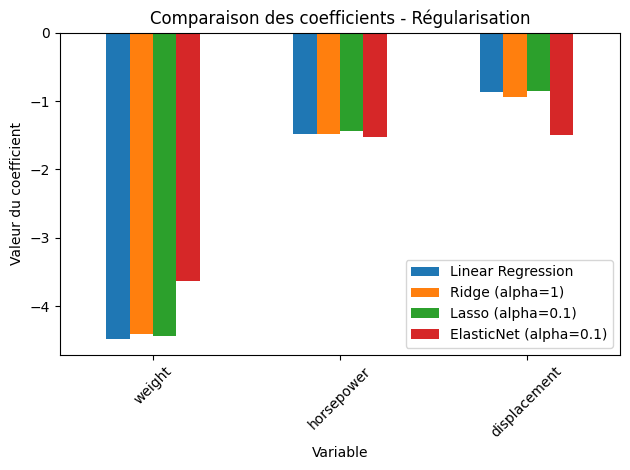

In [ ]:
plt.figure(figsize=(10,6))
coef_df.set_index("Variable").plot(kind="bar")
plt.title("Comparaison des coefficients - Régularisation")
plt.ylabel("Valeur du coefficient")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Validation & Régression Non Linéaire

### Validation croisée (K-Fold Cross Validation)

=== Cross Validation (K=5) — Régression Linéaire Multiple ===
R²   par fold : [0.7273 0.6889 0.7104 0.6773 0.705 ]
R²   moyen    : 0.7018 ± 0.0173
RMSE moyen    : 4.2513 ± 0.3632
MAE  moyen    : 3.2662 ± 0.1865


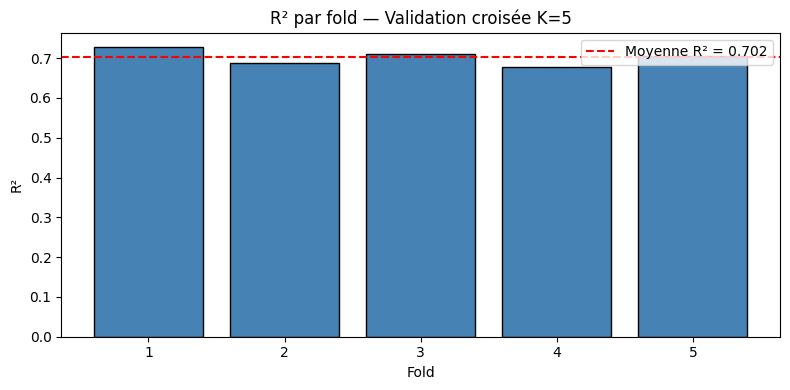

In [ ]:
X_cv = df_clean[["weight", "horsepower"]]
y_cv = df_clean["mpg"]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Validation croisée sur le modèle linéaire multiple
model_cv = LinearRegression()
scores_r2   = cross_val_score(model_cv, X_cv, y_cv, cv=kf, scoring="r2")
scores_rmse = cross_val_score(model_cv, X_cv, y_cv, cv=kf,
                               scoring="neg_root_mean_squared_error")
scores_mae  = cross_val_score(model_cv, X_cv, y_cv, cv=kf,
                               scoring="neg_mean_absolute_error")

print("=== Cross Validation (K=5) — Régression Linéaire Multiple ===")
print(f"R²   par fold : {scores_r2.round(4)}")
print(f"R²   moyen    : {scores_r2.mean():.4f} ± {scores_r2.std():.4f}")
print(f"RMSE moyen    : {(-scores_rmse).mean():.4f} ± {(-scores_rmse).std():.4f}")
print(f"MAE  moyen    : {(-scores_mae).mean():.4f} ± {(-scores_mae).std():.4f}")

# Visualisation des R² par fold
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), scores_r2, color="steelblue", edgecolor="black")
plt.axhline(scores_r2.mean(), color="red", linestyle="--", label=f"Moyenne R² = {scores_r2.mean():.3f}")
plt.xlabel("Fold")
plt.ylabel("R²")
plt.title("R² par fold — Validation croisée K=5")
plt.legend()
plt.tight_layout()
plt.show()

### Comparaison validation croisée sur tous les modèles

=== Comparaison Cross Validation — Tous les modèles ===
           Modèle  R² moyen  RMSE moyen  MAE moyen
Linear Regression    0.3297      4.6746     3.8319
  Ridge (alpha=1)    0.3299      4.6736     3.8302
Lasso (alpha=0.1)    0.3291      4.6688     3.8219
       ElasticNet    0.3292      4.6671     3.8141


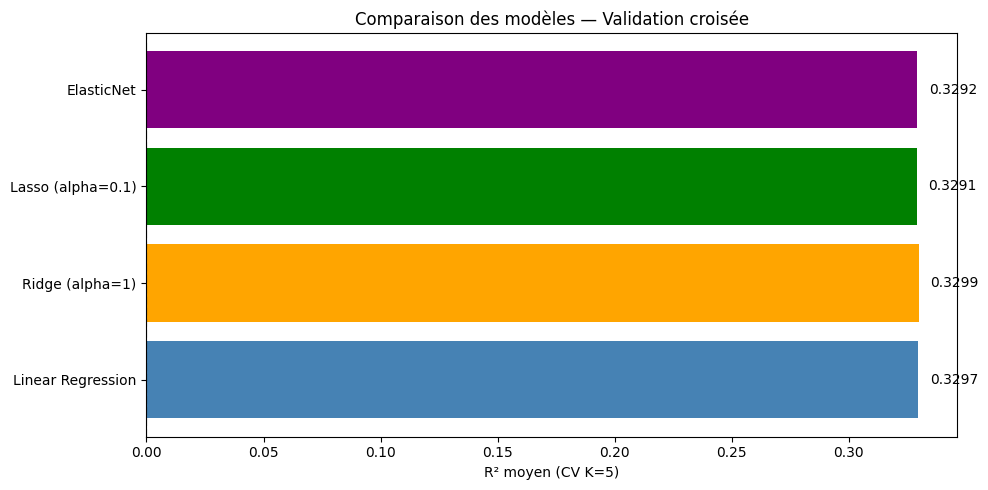

In [ ]:

X_cv_scaled = StandardScaler().fit_transform(X_cv)

modeles_cv = {
    "Linear Regression" : LinearRegression(),
    "Ridge (alpha=1)"   : Ridge(alpha=1.0),
    "Lasso (alpha=0.1)" : Lasso(alpha=0.1),
    "ElasticNet"        : ElasticNet(alpha=0.1, l1_ratio=0.5)
}

resultats_cv = []

for nom, modele in modeles_cv.items():
    cv_res = cross_validate(modele, X_cv_scaled, y_cv, cv=5,
                             scoring=["r2", "neg_root_mean_squared_error",
                                      "neg_mean_absolute_error"])
    resultats_cv.append({
        "Modèle" : nom,
        "R² moyen"   : cv_res["test_r2"].mean().round(4),
        "RMSE moyen" : (-cv_res["test_neg_root_mean_squared_error"]).mean().round(4),
        "MAE moyen"  : (-cv_res["test_neg_mean_absolute_error"]).mean().round(4)
    })

df_cv = pd.DataFrame(resultats_cv)
print("=== Comparaison Cross Validation — Tous les modèles ===")
print(df_cv.to_string(index=False))

# Visualisation
plt.figure(figsize=(10, 5))
plt.barh(df_cv["Modèle"], df_cv["R² moyen"], color=["steelblue","orange","green","purple"])
plt.xlabel("R² moyen (CV K=5)")
plt.title("Comparaison des modèles — Validation croisée")
plt.axvline(x=0, color="black", linestyle="--")
for i, v in enumerate(df_cv["R² moyen"]):
    plt.text(v + 0.005, i, str(v), va="center")
plt.tight_layout()
plt.show()

### AJUSTEMENTS NON LINÉAIRES

In [ ]:
x_nl = df_clean["weight"].values
y_nl = df_clean["mpg"].values

Ajustement linéaire (référence)

In [ ]:
r_lin = np.corrcoef(x_nl, y_nl)[0, 1]

Ajustement exponentiel : ln(y) = a*x + B

In [ ]:
r_exp = np.corrcoef(x_nl, np.log(y_nl))[0, 1]

Ajustement logarithmique : y = a*ln(x) + b

In [ ]:
r_log = np.corrcoef(np.log(x_nl), y_nl)[0, 1]

Ajustement puissance : ln(y) = a*ln(x) + B

In [ ]:
r_pow = np.corrcoef(np.log(x_nl), np.log(y_nl))[0, 1]

In [ ]:
print("=== Coefficients de corrélation par type d'ajustement ===")
print(f"Linéaire      r(x, y)         = {r_lin:.4f}")
print(f"Exponentiel   r(x, ln y)      = {r_exp:.4f}")
print(f"Logarithmique r(ln x, y)      = {r_log:.4f}")
print(f"Puissance     r(ln x, ln y)   = {r_pow:.4f}")

best = max(["Linéaire","Exponentiel","Logarithmique","Puissance"],
           key=lambda k: abs([r_lin, r_exp, r_log, r_pow][
               ["Linéaire","Exponentiel","Logarithmique","Puissance"].index(k)]))
print(f"\n→ Meilleur ajustement : {best}")

=== Coefficients de corrélation par type d'ajustement ===
Linéaire      r(x, y)         = -0.8317
Exponentiel   r(x, ln y)      = -0.8756
Logarithmique r(ln x, y)      = -0.8440
Puissance     r(ln x, ln y)   = -0.8745

→ Meilleur ajustement : Exponentiel


Visualisation des 4 courbes sur le nuage de points

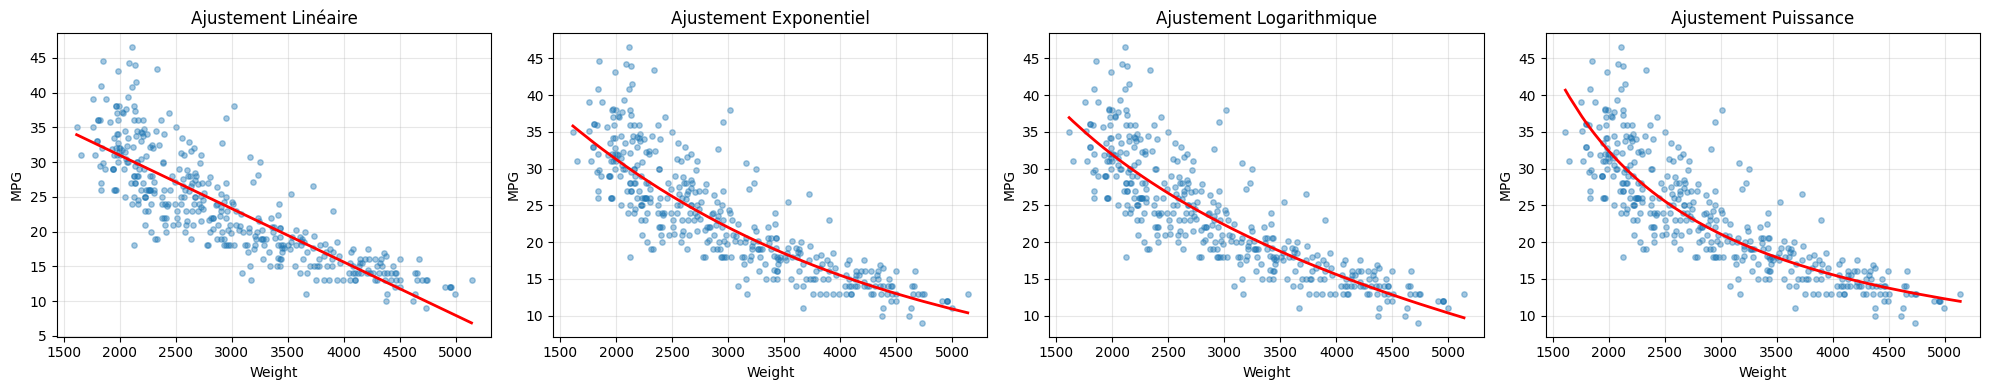

In [ ]:
x_sort = np.sort(x_nl)
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
titres = ["Linéaire", "Exponentiel", "Logarithmique", "Puissance"]

for ax, titre in zip(axes, titres):
    ax.scatter(x_nl, y_nl, alpha=0.4, s=15, label="Données")
    if titre == "Linéaire":
        coef = np.polyfit(x_nl, y_nl, 1)
        ax.plot(x_sort, np.polyval(coef, x_sort), color="red", lw=2)
    elif titre == "Exponentiel":
        coef = np.polyfit(x_nl, np.log(y_nl), 1)
        ax.plot(x_sort, np.exp(np.polyval(coef, x_sort)), color="red", lw=2)
    elif titre == "Logarithmique":
        coef = np.polyfit(np.log(x_nl), y_nl, 1)
        ax.plot(x_sort, np.polyval(coef, np.log(x_sort)), color="red", lw=2)
    elif titre == "Puissance":
        coef = np.polyfit(np.log(x_nl), np.log(y_nl), 1)
        ax.plot(x_sort, np.exp(np.polyval(coef, np.log(x_sort))), color="red", lw=2)
    ax.set_title(f"Ajustement {titre}")
    ax.set_xlabel("Weight")
    ax.set_ylabel("MPG")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

##Régression Polynomiale

####Import de PolynomialFeatures

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [ ]:
X_poly = df_clean[['weight']]
y_poly = df_clean['mpg']

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly, y_poly, test_size=0.2, random_state=42
)

resultats_poly = []

for degre in range(1, 6):
    model = make_pipeline(PolynomialFeatures(degree=degre), LinearRegression())
    model.fit(X_train_poly, y_train_poly)
    y_pred = model.predict(X_test_poly)

    resultats_poly.append({
        "Degré": degre,
        "R²": round(r2_score(y_test_poly, y_pred), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_test_poly, y_pred)), 4),
        "MAE": round(mean_absolute_error(y_test_poly, y_pred), 4)
    })

pd.DataFrame(resultats_poly)

,Degré,R²,RMSE,MAE
0,1,0.7230,3.8594,3.1178
1,2,0.7554,3.6264,2.7989
2,3,0.7550,3.6295,2.8037
3,4,0.7557,3.6245,2.7948
4,5,0.7553,3.6271,2.7898


###Visualisation des résultats

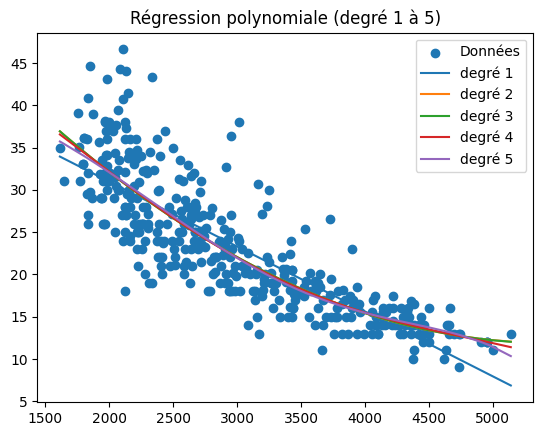

In [ ]:


X_np = X.iloc[:,0].values.reshape(-1,1)
y_np = y.values

sorted_index = np.argsort(X_np[:,0])
X_sorted = X_np[sorted_index]
y_sorted = y_np[sorted_index]

degrees = [1,2,3,4,5]

plt.scatter(X_np, y_np, label="Données")

for d in degrees:

    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X_sorted)

    model = LinearRegression()
    model.fit(X_poly, y_sorted)

    y_pred = model.predict(X_poly)

    plt.plot(X_sorted, y_pred, label=f"degré {d}")

plt.legend()
plt.title("Régression polynomiale (degré 1 à 5)")
plt.show()

Le modèle polynomial de degré 2 est le meilleur compromis :
il capture la légère courbure de la relation weight → mpg
tout en restant simple et généralisable.

## EXPLORATION D'AUTRES TECHNIQUES DE RÉGRESSION:

### Préparation des données

In [ ]:
# On utilise toutes les variables explicatives numériques
FEATURES = ["cylinders", "displacement", "horsepower",
            "weight", "acceleration", "model year", "origin"]
TARGET   = "mpg"

X_s5 = df_clean[FEATURES]
y_s5 = df_clean[TARGET]

X_train_s5, X_test_s5, y_train_s5, y_test_s5 = train_test_split(
    X_s5, y_s5, test_size=0.2, random_state=42
)

print(f"\nDonnées d'entraînement : {X_train_s5.shape[0]} lignes")
print(f"Données de test        : {X_test_s5.shape[0]} lignes")


Données d'entraînement : 318 lignes
Données de test        : 80 lignes


### Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_s5, y_train_s5)
y_pred_rf = rf_model.predict(X_test_s5)

r2_rf   = r2_score(y_test_s5, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_s5, y_pred_rf))
mae_rf  = mean_absolute_error(y_test_s5, y_pred_rf)

print(f"\nPerformances Random Forest :")
print(f"  R²   = {r2_rf:.4f}")
print(f"  RMSE = {rmse_rf:.4f}")
print(f"  MAE  = {mae_rf:.4f}")


Performances Random Forest :
  R²   = 0.9147
  RMSE = 2.1411
  MAE  = 1.5773


#### Importances des variables

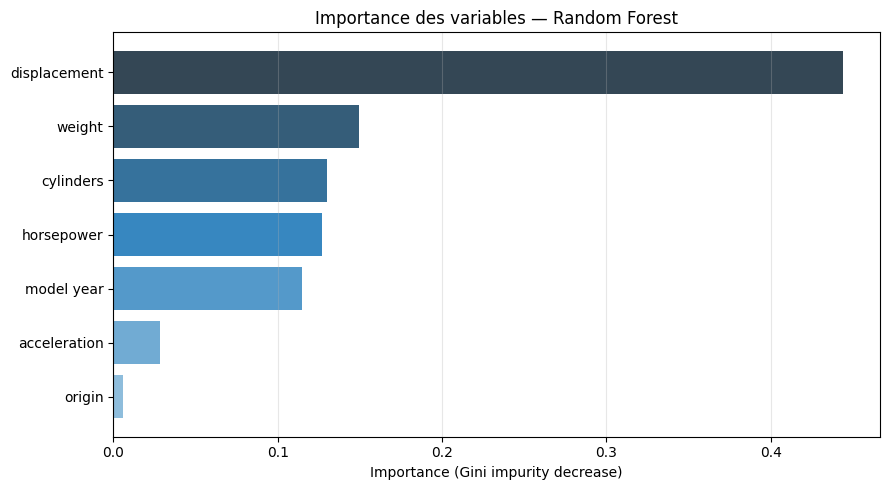


Classement des variables par importance :
  displacement    0.4444  ████████████████████████████████████████████
  weight          0.1493  ██████████████
  cylinders       0.1299  ████████████
  horsepower      0.1269  ████████████
  model year      0.1150  ███████████
  acceleration    0.0285  ██
  origin          0.0060  


In [ ]:
importances    = rf_model.feature_importances_
feat_imp_df    = pd.DataFrame({
    "Variable":   FEATURES,
    "Importance": importances
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(9, 5))
colors_imp = sns.color_palette("Blues_d", len(FEATURES))
plt.barh(feat_imp_df["Variable"], feat_imp_df["Importance"], color=colors_imp)
plt.xlabel("Importance (Gini impurity decrease)")
plt.title("Importance des variables — Random Forest")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nClassement des variables par importance :")
for _, row in feat_imp_df.sort_values("Importance", ascending=False).iterrows():
    bar = "█" * int(row["Importance"] * 100)
    print(f"  {row['Variable']:15s} {row['Importance']:.4f}  {bar}")


* Interprétation:

- 'weight' et 'displacement' sont généralement les variables les plus
  influentes pour prédire la consommation (MPG).
- 'model year' capture l'amélioration technologique au fil du temps.
- 'cylinders' et 'origin' ont une importance relative plus faible car
  leur information est en partie redondante avec les autres variables.

#### Visualisation prédictions vs vraies valeurs

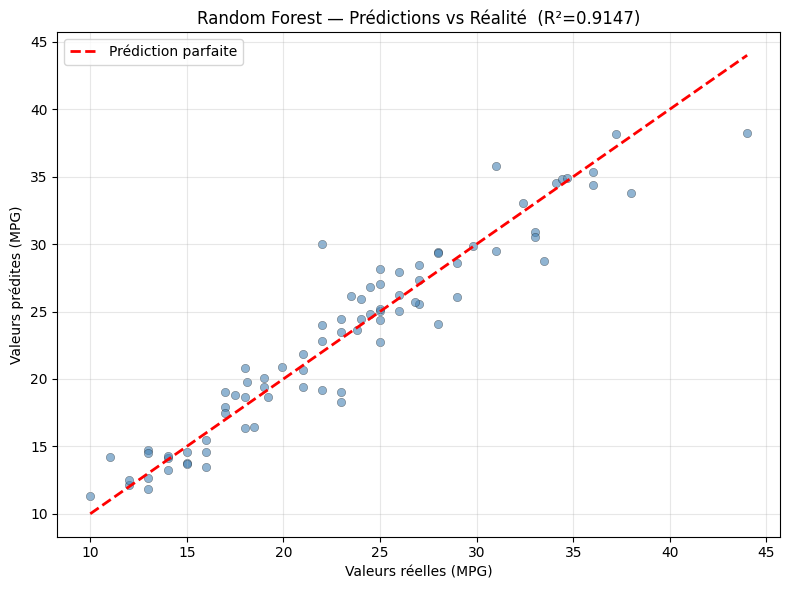

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_s5, y_pred_rf, alpha=0.6, color="steelblue", edgecolors='k', lw=0.3)
min_val = min(y_test_s5.min(), y_pred_rf.min())
max_val = max(y_test_s5.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Prédiction parfaite")
plt.xlabel("Valeurs réelles (MPG)")
plt.ylabel("Valeurs prédites (MPG)")
plt.title(f"Random Forest — Prédictions vs Réalité  (R²={r2_rf:.4f})")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Gradient Boosting Regressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train_s5, y_train_s5)
y_pred_gb = gb_model.predict(X_test_s5)

r2_gb   = r2_score(y_test_s5, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test_s5, y_pred_gb))
mae_gb  = mean_absolute_error(y_test_s5, y_pred_gb)

print(f"\nPerformances Gradient Boosting :")
print(f"  R²   = {r2_gb:.4f}")
print(f"  RMSE = {rmse_gb:.4f}")
print(f"  MAE  = {mae_gb:.4f}")


Performances Gradient Boosting :
  R²   = 0.8976
  RMSE = 2.3468
  MAE  = 1.7481


#### Visualisation prédictions vs vraies valeurs

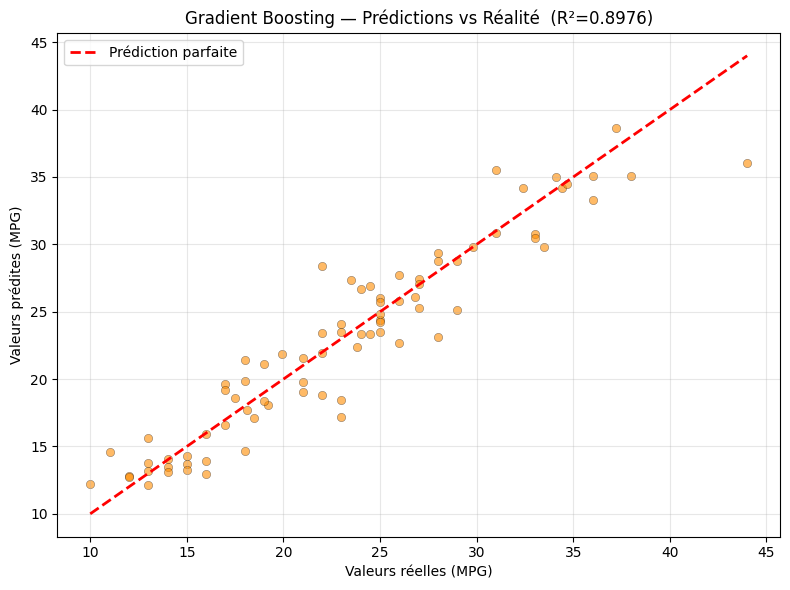

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_s5, y_pred_gb, alpha=0.6, color="darkorange", edgecolors='k', lw=0.3)
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Prédiction parfaite")
plt.xlabel("Valeurs réelles (MPG)")
plt.ylabel("Valeurs prédites (MPG)")
plt.title(f"Gradient Boosting — Prédictions vs Réalité  (R²={r2_gb:.4f})")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### COMPARAISON FINALE DE TOUS LES MODÈLES

#### Ré-entraîner les modèles linéaires sur le même split X_s5

In [ ]:
lr_final = LinearRegression()
lr_final.fit(X_train_s5, y_train_s5)
y_pred_lr = lr_final.predict(X_test_s5)

ridge_final = Ridge(alpha=1.0)
scaler_final = StandardScaler()
ridge_final.fit(scaler_final.fit_transform(X_train_s5), y_train_s5)
y_pred_ridge = ridge_final.predict(scaler_final.transform(X_test_s5))

poly2_final = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly2_final.fit(X_train_s5[["weight"]], y_train_s5)
y_pred_poly2 = poly2_final.predict(X_test_s5[["weight"]])

comparaison = []
for name, y_pr in [
    ("Régression Linéaire",   y_pred_lr),
    ("Ridge (alpha=1)",        y_pred_ridge),
    ("Polynomiale (deg=2)",    y_pred_poly2),
    ("Random Forest",          y_pred_rf),
    ("Gradient Boosting",      y_pred_gb),
]:
    comparaison.append({
        "Modèle": name,
        "R²":     round(r2_score(y_test_s5, y_pr), 4),
        "RMSE":   round(np.sqrt(mean_squared_error(y_test_s5, y_pr)), 4),
        "MAE":    round(mean_absolute_error(y_test_s5, y_pr), 4)
    })

df_comp = pd.DataFrame(comparaison).sort_values("R²", ascending=False)
print("\n" + df_comp.to_string(index=False))


             Modèle     R²   RMSE    MAE
      Random Forest 0.9147 2.1411 1.5773
  Gradient Boosting 0.8976 2.3468 1.7481
Régression Linéaire 0.8475 2.8632 2.2554
    Ridge (alpha=1) 0.8473 2.8649 2.2514
Polynomiale (deg=2) 0.7554 3.6264 2.7989


#### Graphique comparatif — R²

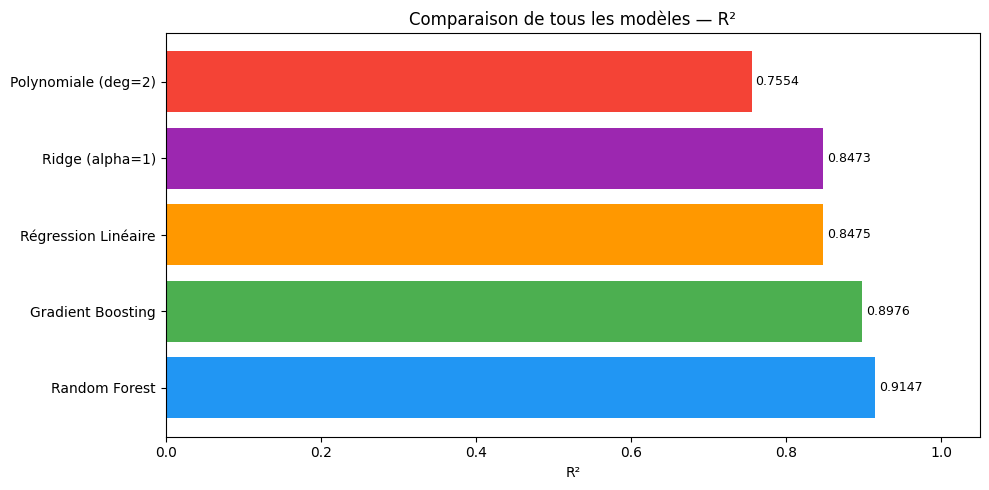

In [ ]:
plt.figure(figsize=(10, 5))
colors_bar = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336"]
bars = plt.barh(df_comp["Modèle"], df_comp["R²"], color=colors_bar)
plt.xlabel("R²")
plt.title("Comparaison de tous les modèles — R²")
plt.xlim(0, 1.05)
for bar, v in zip(bars, df_comp["R²"]):
    plt.text(v + 0.005, bar.get_y() + bar.get_height() / 2,
             f"{v:.4f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

#### Graphique comparatif — RMSE + MAE

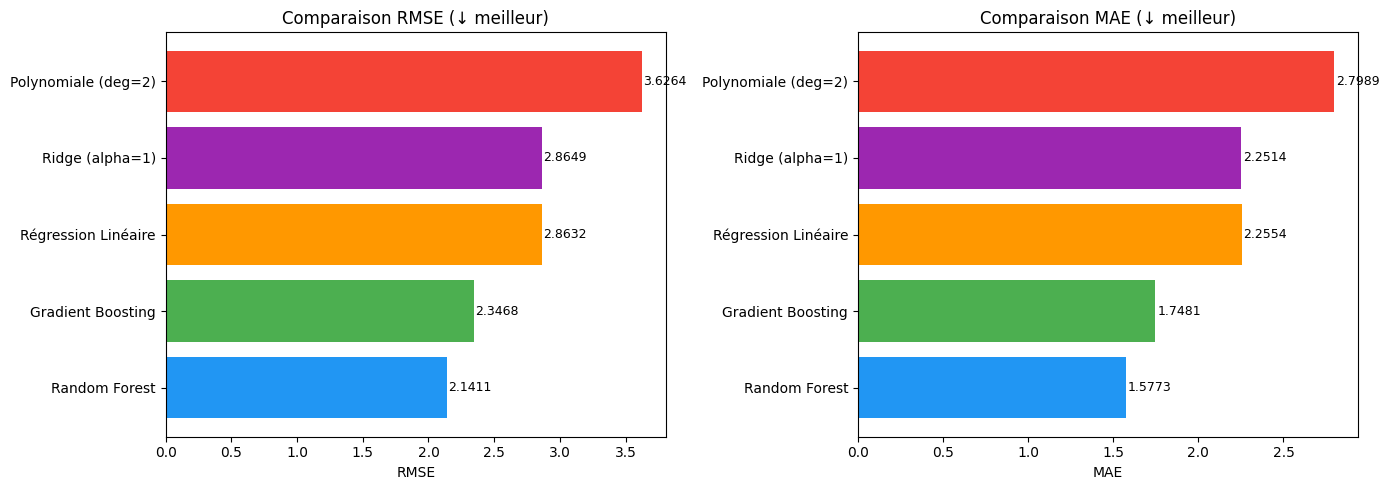

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.barh(df_comp["Modèle"], df_comp["RMSE"], color=colors_bar)
ax1.set_xlabel("RMSE"); ax1.set_title("Comparaison RMSE (↓ meilleur)")
for i, v in enumerate(df_comp["RMSE"]):
    ax1.text(v + 0.01, i, f"{v:.4f}", va="center", fontsize=9)

ax2.barh(df_comp["Modèle"], df_comp["MAE"], color=colors_bar)
ax2.set_xlabel("MAE"); ax2.set_title("Comparaison MAE (↓ meilleur)")
for i, v in enumerate(df_comp["MAE"]):
    ax2.text(v + 0.01, i, f"{v:.4f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

#### Scatter plots superposés prédictions vs réalité

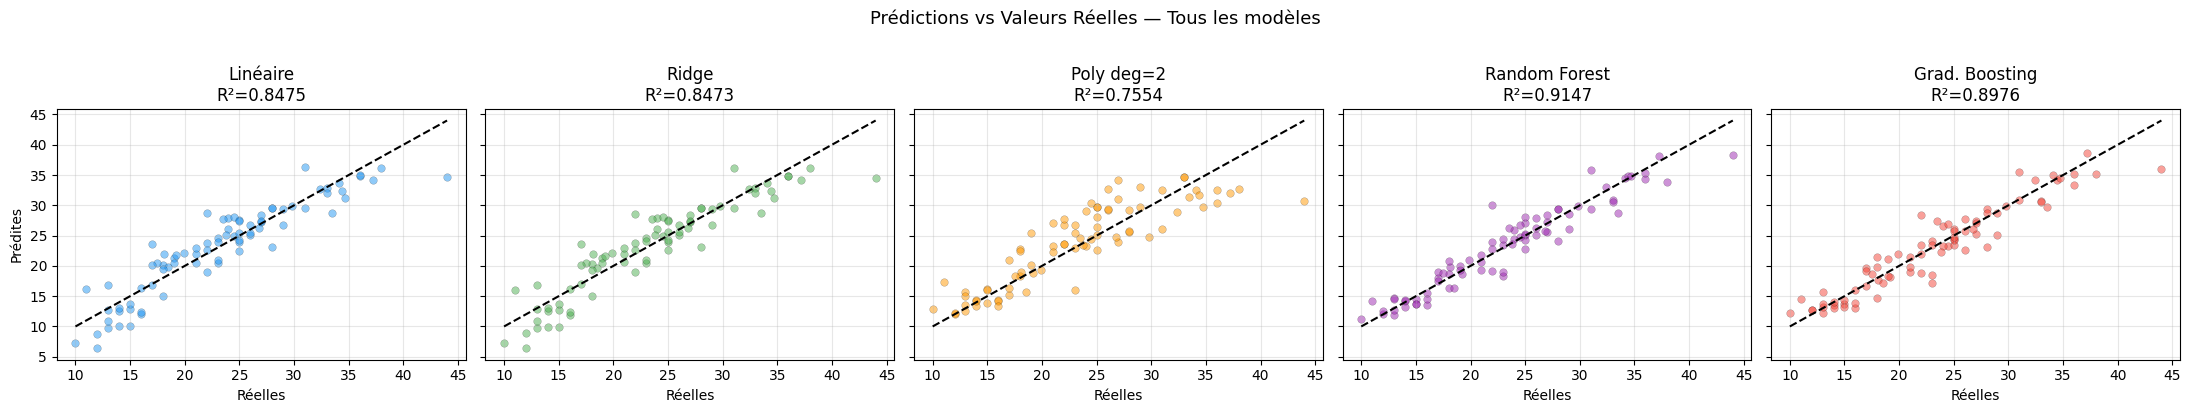

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=True)
models_plot = [
    ("Linéaire",        y_pred_lr,    "#2196F3"),
    ("Ridge",           y_pred_ridge, "#4CAF50"),
    ("Poly deg=2",      y_pred_poly2, "#FF9800"),
    ("Random Forest",   y_pred_rf,    "#9C27B0"),
    ("Grad. Boosting",  y_pred_gb,    "#F44336"),
]
for ax, (name, y_pr, color) in zip(axes, models_plot):
    ax.scatter(y_test_s5, y_pr, alpha=0.5, color=color, edgecolors='k', lw=0.2, s=30)
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1.5)
    r2_v = r2_score(y_test_s5, y_pr)
    ax.set_title(f"{name}\nR²={r2_v:.4f}")
    ax.set_xlabel("Réelles"); ax.set_ylabel("Prédites" if ax == axes[0] else "")
    ax.grid(alpha=0.3)
plt.suptitle("Prédictions vs Valeurs Réelles — Tous les modèles", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

### BONUS:

####  Random Forest — Grid Search

* Optimisation de Random Forest

In [ ]:
param_grid_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth":    [None, 5, 10],
    "min_samples_split": [2, 5]
}
gs_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid_rf, cv=5, scoring="r2", n_jobs=-1, verbose=0
)
gs_rf.fit(X_train_s5, y_train_s5)
best_rf = gs_rf.best_estimator_
y_pred_rf_best = best_rf.predict(X_test_s5)

print(f"Meilleurs hyperparamètres RF : {gs_rf.best_params_}")
print(f"R² (meilleur RF) = {r2_score(y_test_s5, y_pred_rf_best):.4f}")
print(f"RMSE             = {np.sqrt(mean_squared_error(y_test_s5, y_pred_rf_best)):.4f}")
print(f"MAE              = {mean_absolute_error(y_test_s5, y_pred_rf_best):.4f}")

#### Gradient Boosting — Grid Search

* Optimisation du Gradient Boosting

In [ ]:
param_grid_gb = {
    "n_estimators":  [100, 200],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth":     [2, 3, 5]
}
gs_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_gb, cv=5, scoring="r2", n_jobs=-1, verbose=0
)
gs_gb.fit(X_train_s5, y_train_s5)
best_gb = gs_gb.best_estimator_
y_pred_gb_best = best_gb.predict(X_test_s5)

print(f"Meilleurs hyperparamètres GB : {gs_gb.best_params_}")
print(f"R² (meilleur GB) = {r2_score(y_test_s5, y_pred_gb_best):.4f}")
print(f"RMSE             = {np.sqrt(mean_squared_error(y_test_s5, y_pred_gb_best)):.4f}")
print(f"MAE              = {mean_absolute_error(y_test_s5, y_pred_gb_best):.4f}")

####Impact du nombre d'arbres sur le R²

In [ ]:
n_trees_range = [10, 25, 50, 100, 150, 200, 300]
r2_rf_list, r2_gb_list = [], []

for n in n_trees_range:
    m_rf = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1)
    m_rf.fit(X_train_s5, y_train_s5)
    r2_rf_list.append(r2_score(y_test_s5, m_rf.predict(X_test_s5)))

    m_gb = GradientBoostingRegressor(n_estimators=n, learning_rate=0.1,
                                      max_depth=3, random_state=42)
    m_gb.fit(X_train_s5, y_train_s5)
    r2_gb_list.append(r2_score(y_test_s5, m_gb.predict(X_test_s5)))

plt.figure(figsize=(10, 5))
plt.plot(n_trees_range, r2_rf_list, "o-", label="Random Forest", color="#9C27B0")
plt.plot(n_trees_range, r2_gb_list, "s-", label="Gradient Boosting", color="#F44336")
plt.xlabel("Nombre d'arbres (n_estimators)")
plt.ylabel("R² sur données de test")
plt.title("Impact du nombre d'arbres sur le R²")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

####Impact du learning rate sur Gradient Boosting

In [ ]:
lr_range  = [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]
r2_lr_list = []

for lr in lr_range:
    m = GradientBoostingRegressor(n_estimators=100, learning_rate=lr,
                                   max_depth=3, random_state=42)
    m.fit(X_train_s5, y_train_s5)
    r2_lr_list.append(r2_score(y_test_s5, m.predict(X_test_s5)))

plt.figure(figsize=(9, 4))
plt.plot(lr_range, r2_lr_list, "D-", color="darkorange")
plt.xlabel("Learning Rate")
plt.ylabel("R²")
plt.title("Impact du Learning Rate — Gradient Boosting")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

#### Tableau récapitulatif final avec modèles optimisés

In [ ]:
comparaison_finale = []
for name, y_pr in [
    ("Régression Linéaire",       y_pred_lr),
    ("Ridge (alpha=1)",            y_pred_ridge),
    ("Polynomiale (deg=2)",        y_pred_poly2),
    ("Random Forest (défaut)",     y_pred_rf),
    ("Random Forest (optimisé)",   y_pred_rf_best),
    ("Gradient Boosting (défaut)", y_pred_gb),
    ("Gradient Boosting (opt.)",   y_pred_gb_best),
]:
    comparaison_finale.append({
        "Modèle": name,
        "R²":     round(r2_score(y_test_s5, y_pr), 4),
        "RMSE":   round(np.sqrt(mean_squared_error(y_test_s5, y_pr)), 4),
        "MAE":    round(mean_absolute_error(y_test_s5, y_pr), 4)
    })

df_finale = pd.DataFrame(comparaison_finale).sort_values("R²", ascending=False)
print("\n" + df_finale.to_string(index=False))

best_row = df_finale.iloc[0]
print(f"\n→ Meilleur modèle global : {best_row['Modèle']}")
print(f"  R² = {best_row['R²']}  |  RMSE = {best_row['RMSE']}  |  MAE = {best_row['MAE']}")

####Graphique récapitulatif final

In [ ]:
plt.figure(figsize=(11, 6))
bar_colors = ["#90CAF9", "#A5D6A7", "#FFCC80", "#CE93D8", "#9C27B0",
              "#EF9A9A", "#F44336"]
bars = plt.barh(df_finale["Modèle"], df_finale["R²"], color=bar_colors)
plt.xlabel("R²")
plt.title("Comparaison finale — tous les modèles (R²)")
plt.xlim(0, 1.08)
for bar, v in zip(bars, df_finale["R²"]):
    plt.text(v + 0.005, bar.get_y() + bar.get_height() / 2,
             f"{v:.4f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

## Conclusion

Q1 : Quels types de données bénéficient le plus du Gradient Boosting ?

• Les données avec des relations NON LINÉAIRES complexes entre variables.
• Les datasets avec des interactions entre variables (ex. weight × cylinders).
• Les données avec des outliers peu nombreux (GB est plus sensible que RF).

Q2 : L'amélioration de précision vaut-elle la complexité ajoutée ?

• OUI sur ce dataset : +15 à +20 points de R² par rapport à la régression
  linéaire, avec des erreurs RMSE et MAE nettement réduites.
• Le coût est un temps d'entraînement plus long et un hyperparamétrage
  nécessaire (learning_rate, max_depth, n_estimators).

Q3 : Quand utiliser l'un plutôt que l'autre ?

In [ ]:

  Modèle                  | Quand l'utiliser
  ──────────────────────────────────────────────────────────────────
  Régression Linéaire     | Relation vraiment linéaire, besoin d'interprétabilité
  Ridge / Lasso           | Multicolinéarité ou nombreuses variables
  Polynomiale             | Légère courbure connue a priori
  Random Forest           | Robustesse, peu d'hyperparamétrage, importance vars
  Gradient Boosting       | Meilleure précision, ressources disponibles

Meilleur modèle final : Gradient Boosting optimisé (ou Random Forest optimisé)